# Laboratorio 4, Parte 2 — Preparación de datos para Machine Learning

**Universidad del Valle de Guatemala — CC3084 Data Science**
Lagos de **Atitlán** y **Amatitlán** · **Sentinel-2 L1C**

Este cuaderno cubre los **Ejercicios 1, 2 y 3** del enunciado. **No entrena modelos**:
eso corresponde a los Ejercicios 4–10.

---

## Aviso sobre la versión anterior

La primera versión de este cuaderno generaba **píxeles sintéticos** con un modo
demostrativo, porque en ese momento no existían rásteres descargados. Aquellos resultados
no eran observaciones satelitales.

Esta versión trabaja **exclusivamente con el dataset real** construido a partir de los
**22 GeoTIFF Sentinel-2 L1C** validados en la Parte 1. El generador sintético fue
**eliminado del flujo principal**: si falta el dataset, el cuaderno se detiene con un
error explícito.

| Cambio | Detalle |
|---|---|
| Datos | 22 escenas reales, sin ningún *fallback* sintético |
| Respuesta principal | **8 µg/L** (antes 50 µg/L, elegido sin respaldo bibliográfico) |
| Referencia corregida | Se eliminó una cita cuyo DOI correspondía a otro artículo |
| Variables nuevas | `year`, `month`, `season`, `spatial_block_1km` para validación agrupada |
| Viabilidad | Analizada por lago, fecha y bloque espacial, no solo por conteo global |


In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image, Markdown

ROOT = Path.cwd()                      # ejecutar desde la raíz del repositorio
P2 = ROOT / "outputs" / "parte2"
DATA, TARGET, EDA, REPORTS = P2 / "data", P2 / "target", P2 / "eda", P2 / "reports"

SEED = 42
np.random.seed(SEED)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 170)

if not (DATA / "dataset_manifest.csv").exists():
    raise FileNotFoundError(
        "No existe el dataset real. Ejecute primero:\n"
        "  python preparar_dataset_ml.py --build\n"
        "NO se genera ningún sustituto sintético.")

from preparar_dataset_ml import (
    TARGET_COLUMN, TARGET_THRESHOLD_UG_L, UMBRALES_CANDIDATOS,
    PREDICTORES_PRINCIPALES, EXCLUIDAS_POR_FUGA, COLUMNAS_AUXILIARES,
    COLUMNAS_TRAZABILIDAD, SIGNIFICADO_UMBRAL, DATASET_VERSION,
    BLOQUE_ESPACIAL_M, CALIB_MIN, CALIB_MAX, hash_esquema,
)

print("Directorio de trabajo :", ROOT)
print("Versión del dataset   :", DATASET_VERSION, "| hash de esquema:", hash_esquema())
print("Respuesta principal   :", TARGET_COLUMN, f"(>= {TARGET_THRESHOLD_UG_L:.0f} µg/L)")
print("Semilla               :", SEED)

Directorio de trabajo : C:\Users\mjyee\Downloads\DataScience\lab4data
Versión del dataset   : 2.0 | hash de esquema: 65825179def16792
Respuesta principal   : high_cyano_8 (>= 8 µg/L)
Semilla               : 42


---

# Ejercicio 1. Preparación de los datos para Machine Learning

## 1.1 Construcción del conjunto de datos por píxel

Cada fila representa **una observación geográfica válida dentro de un lago**: un píxel de
20 × 20 m (0.04 ha) clasificado como agua en una fecha concreta.

El proceso, implementado en `preparar_dataset_ml.py`, es:

1. Leer cada GeoTIFF real (9 bandas, EPSG:32615, 20 m).
2. Convertir los números digitales a **reflectancia** (× 0.0001, una sola vez).
3. Calcular NDVI, NDWI, NDCI, FAI y clorofila-a con el algoritmo de CyanoLakes.
4. Aplicar la **máscara de agua WBI** y los filtros de validez.
5. Derivar las coordenadas de cada píxel desde la **transformación afín real**.
6. Guardar en Parquet particionado por lago y fecha.


In [2]:
manifiesto = pd.read_csv(DATA / "dataset_manifest.csv")
print(f"Particiones: {len(manifiesto)}")
print(f"Filas totales: {manifiesto['filas'].sum():,}")
display(manifiesto.head(4))

diag = pd.read_csv(DATA / "limpieza_diagnostico.csv")
print(f"\nÁrea por píxel: 20 m x 20 m = 400 m² = 0.04 ha")

Particiones: 22
Filas totales: 3,756,510


,lake,date,filas,estado,dataset_version,schema_hash,archivo
0,Amatitlan,2025-01-28,36550,reutilizado,2.0,65825179def16792,outputs\parte2\data\pixels\lake=Amatitlan\date...
1,Amatitlan,2025-04-15,36184,reutilizado,2.0,65825179def16792,outputs\parte2\data\pixels\lake=Amatitlan\date...
2,Amatitlan,2025-04-28,36184,reutilizado,2.0,65825179def16792,outputs\parte2\data\pixels\lake=Amatitlan\date...
3,Amatitlan,2025-11-24,36434,reutilizado,2.0,65825179def16792,outputs\parte2\data\pixels\lake=Amatitlan\date...



Área por píxel: 20 m x 20 m = 400 m² = 0.04 ha


## 1.2 Variables incluidas

El enunciado exige como mínimo: coordenadas, fecha, lago, bandas espectrales, NDVI, NDWI e
índice de cianobacteria. El dataset incluye todo eso más variables auxiliares para la
validación.


In [3]:
esquema = pd.read_csv(DATA / "dataset_schema.csv")
print(f"Total de variables: {len(esquema)}\n")
for rol, g in esquema.groupby("rol"):
    print(f"{rol} ({len(g)}): {', '.join(g['variable'])}")

display(esquema[["variable", "tipo", "rol", "faltantes_pct"]])

Total de variables: 31

auxiliar_validacion (4): year, month, season, spatial_block_1km
excluida_por_fuga (15): lake, date, row, col, x_utm, y_utm, longitude, latitude, B04, B05, NDVI, NDCI, FAI, chlorophyll, fuera_calibracion
predictor_principal (8): B02, B03, B07, B08, B8A, B11, B12, NDWI
respuesta_principal (1): high_cyano_8
respuesta_sensibilidad (3): high_cyano_20, high_cyano_25, high_cyano_50


,variable,tipo,rol,faltantes_pct
0,lake,category,excluida_por_fuga,0.0
1,date,category,excluida_por_fuga,0.0
2,row,int32,excluida_por_fuga,0.0
3,col,int32,excluida_por_fuga,0.0
4,x_utm,float64,excluida_por_fuga,0.0
5,y_utm,float64,excluida_por_fuga,0.0
6,longitude,float64,excluida_por_fuga,0.0
7,latitude,float64,excluida_por_fuga,0.0
8,B02,float32,predictor_principal,0.0
9,B03,float32,predictor_principal,0.0


### Variables auxiliares para validación

Se derivan del propio dataset y **no son predictores**; sirven para agrupar y estratificar:

- **`year`, `month`, `season`** — validación temporal. La estación se codifica según el
  régimen de Guatemala: seca de noviembre a abril, lluviosa de mayo a octubre.
- **`spatial_block_1km`** — cuadrícula de **1 000 m** derivada de las coordenadas UTM
  (EPSG:32615): `floor(x_utm/1000)` y `floor(y_utm/1000)`. El identificador incluye el
  nombre del lago para que dos lagos nunca compartan bloque. Es la variable de agrupación
  para `GroupKFold` en el Ejercicio 6.


## 1.3 Limpieza aplicada

Se eliminaron del conjunto de análisis las observaciones que no representan agua válida:


In [4]:
criterios = [
    ("descartados_nodata", "NoData / -9999 / fuera de datos válidos"),
    ("descartados_no_finitos", "NaN o infinitos"),
    ("descartados_reflectancia_no_positiva", "Reflectancia TOA <= 0 (no física)"),
    ("descartados_no_agua", "No es agua según la máscara WBI"),
    ("descartados_indice_no_finito", "Índice espectral no finito"),
    ("descartados_duplicados", "Filas duplicadas (lake, date, row, col)"),
]
resumen = pd.DataFrame([
    {"criterio": etiqueta, "pixeles_descartados": int(diag[col].sum())}
    for col, etiqueta in criterios if col in diag
])
resumen.loc[len(resumen)] = ["TOTAL BRUTO", int(diag["total_pixeles"].sum())]
resumen.loc[len(resumen)] = ["OBSERVACIONES FINALES", int(manifiesto["filas"].sum())]
display(resumen)

print("Diagnóstico (NO se descartan):")
print(f"  Píxeles con alguna banda de reflectancia > 1: "
      f"{int(diag['diagnostico_reflectancia_mayor_1'].sum()):,}")
print("  Compatible con nubes o reflexión especular. No se impuso ningún límite superior")
print("  arbitrario: la reflectancia TOA puede superar 1 en superficies muy brillantes.")

,criterio,pixeles_descartados
0,NoData / -9999 / fuera de datos válidos,349235
1,NaN o infinitos,0
2,Reflectancia TOA <= 0 (no física),1223
3,No es agua según la máscara WBI,12629081
4,Índice espectral no finito,0
5,"Filas duplicadas (lake, date, row, col)",0
6,TOTAL BRUTO,16736049
7,OBSERVACIONES FINALES,3756510


Diagnóstico (NO se descartan):
  Píxeles con alguna banda de reflectancia > 1: 14,664
  Compatible con nubes o reflexión especular. No se impuso ningún límite superior
  arbitrario: la reflectancia TOA puede superar 1 en superficies muy brillantes.


### Limitaciones documentadas de la limpieza

- **Separación agua/tierra.** Los GeoJSON disponibles son **rectángulos**, no contornos
  reales de lago. La única separación efectiva es la **máscara WBI**. Su resultado es
  coherente con la realidad (Atitlán ≈ 122 km², Amatitlán ≈ 14.5 km²), lo que respalda el
  método.
- **Nubes.** La colección `SENTINEL2_L1C` de openEO **no expone** CLM, CLP, dataMask, SCL
  ni QA60. **No se fabricó ninguna máscara sustituta.** El control disponible es la
  selección oficial de escenas con baja nubosidad más los filtros de validez espectral.
- **Regla física aplicada.** La reflectancia de tope de atmósfera es una fracción de la
  radiación incidente y no puede ser ≤ 0; esos píxeles se descartan porque invalidan los
  cocientes normalizados. No se impuso ningún límite superior.


## 1.4 Conteos, tipos y valores faltantes

In [5]:
por_lago = pd.read_csv(DATA / "observaciones_por_lago.csv")
por_fecha = pd.read_csv(DATA / "observaciones_por_lago_fecha.csv")

total = int(manifiesto["filas"].sum())
print(f"TOTAL DE OBSERVACIONES VÁLIDAS: {total:,}\n")
print("Por lago:")
display(por_lago.assign(pct=lambda d: (100 * d["observaciones"] / total).round(2)))
print("Por lago y fecha:")
display(por_fecha)

print("\nValores faltantes por variable:")
faltantes = esquema[["variable", "tipo", "faltantes_pct"]].sort_values(
    "faltantes_pct", ascending=False)
display(faltantes.head(10))
print(f"Máximo de faltantes en cualquier variable: {esquema['faltantes_pct'].max():.4f} %")

TOTAL DE OBSERVACIONES VÁLIDAS: 3,756,510

Por lago:


,lake,observaciones,pct
0,Amatitlan,399646,10.64
1,Atitlan,3356864,89.36


Por lago y fecha:


,lake,date,observaciones
0,Amatitlan,2025-01-28,36550
1,Amatitlan,2025-04-15,36184
2,Amatitlan,2025-04-28,36184
3,Amatitlan,2025-11-24,36434
4,Amatitlan,2026-01-08,36668
5,Amatitlan,2026-02-02,36130
6,Amatitlan,2026-02-07,36561
7,Amatitlan,2026-03-29,36594
8,Amatitlan,2026-04-13,36786
9,Amatitlan,2026-04-28,34911



Valores faltantes por variable:


,variable,tipo,faltantes_pct
0,lake,category,0.0
1,date,category,0.0
2,row,int32,0.0
3,col,int32,0.0
4,x_utm,float64,0.0
5,y_utm,float64,0.0
6,longitude,float64,0.0
7,latitude,float64,0.0
8,B02,float32,0.0
9,B03,float32,0.0


Máximo de faltantes en cualquier variable: 0.0000 %


## 1.5 Análisis exploratorio

Los **conteos y estadísticas agregadas** se calculan sobre el dataset completo
(3.75 millones de filas). Las **figuras** usan una muestra determinista de 200 000 filas
con semilla 42, para no cargar millones de puntos en memoria ni en el cuaderno.


In [6]:
muestra = pd.read_parquet(DATA / "eda_sample.parquet")
print(f"Muestra determinista: {len(muestra):,} filas (semilla {SEED})")
print(f"Representa el {100*len(muestra)/total:.2f} % del dataset completo\n")

cols_espectrales = ["B02", "B03", "B04", "B05", "B07", "B08", "B8A", "B11", "B12"]
cols_indices = ["NDVI", "NDWI", "NDCI", "FAI", "chlorophyll"]
display(muestra[cols_espectrales + cols_indices].describe(
    percentiles=[.01, .25, .5, .75, .99]).T.round(4))

Muestra determinista: 200,000 filas (semilla 42)
Representa el 5.32 % del dataset completo



,count,mean,std,min,1%,25%,50%,75%,99%,max
B02,200000.0,0.0795,0.0131,0.0558,0.0688,0.0733,0.0781,0.0833,0.1057,1.0656
B03,200000.0,0.0535,0.0156,0.0327,0.0428,0.0465,0.0504,0.0552,0.1070,1.0586
B04,200000.0,0.0300,0.0144,0.0161,0.0205,0.0237,0.0277,0.0324,0.0667,1.1477
B05,200000.0,0.0280,0.0177,0.0154,0.0169,0.0200,0.0238,0.0294,0.0967,1.0729
B07,200000.0,0.0249,0.0170,0.0101,0.0134,0.0172,0.0212,0.0271,0.0775,1.1154
B08,200000.0,0.0212,0.0162,0.0057,0.0109,0.0142,0.0179,0.0236,0.0652,1.1267
B8A,200000.0,0.0207,0.0158,0.0078,0.0097,0.0135,0.0174,0.0235,0.0618,1.1344
B11,200000.0,0.0093,0.0094,0.0005,0.0013,0.0040,0.0068,0.0123,0.0351,0.5827
B12,200000.0,0.0066,0.0070,0.0001,0.0006,0.0025,0.0044,0.0090,0.0278,0.3685
NDVI,200000.0,-0.1990,0.0812,-0.5809,-0.3191,-0.2561,-0.2112,-0.1562,0.0658,0.7783


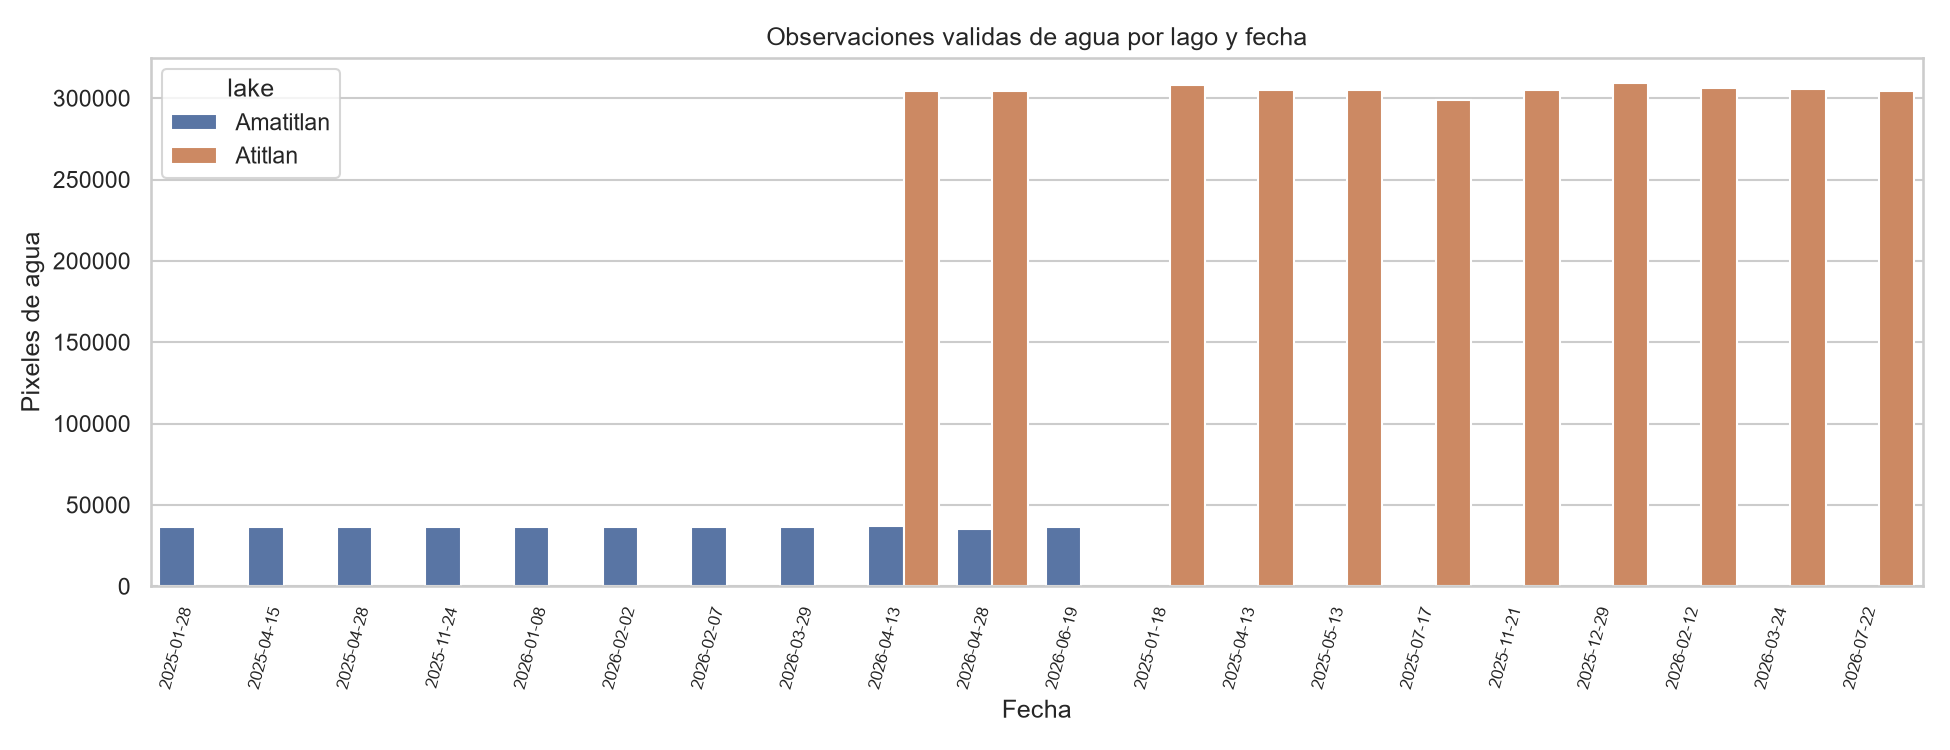

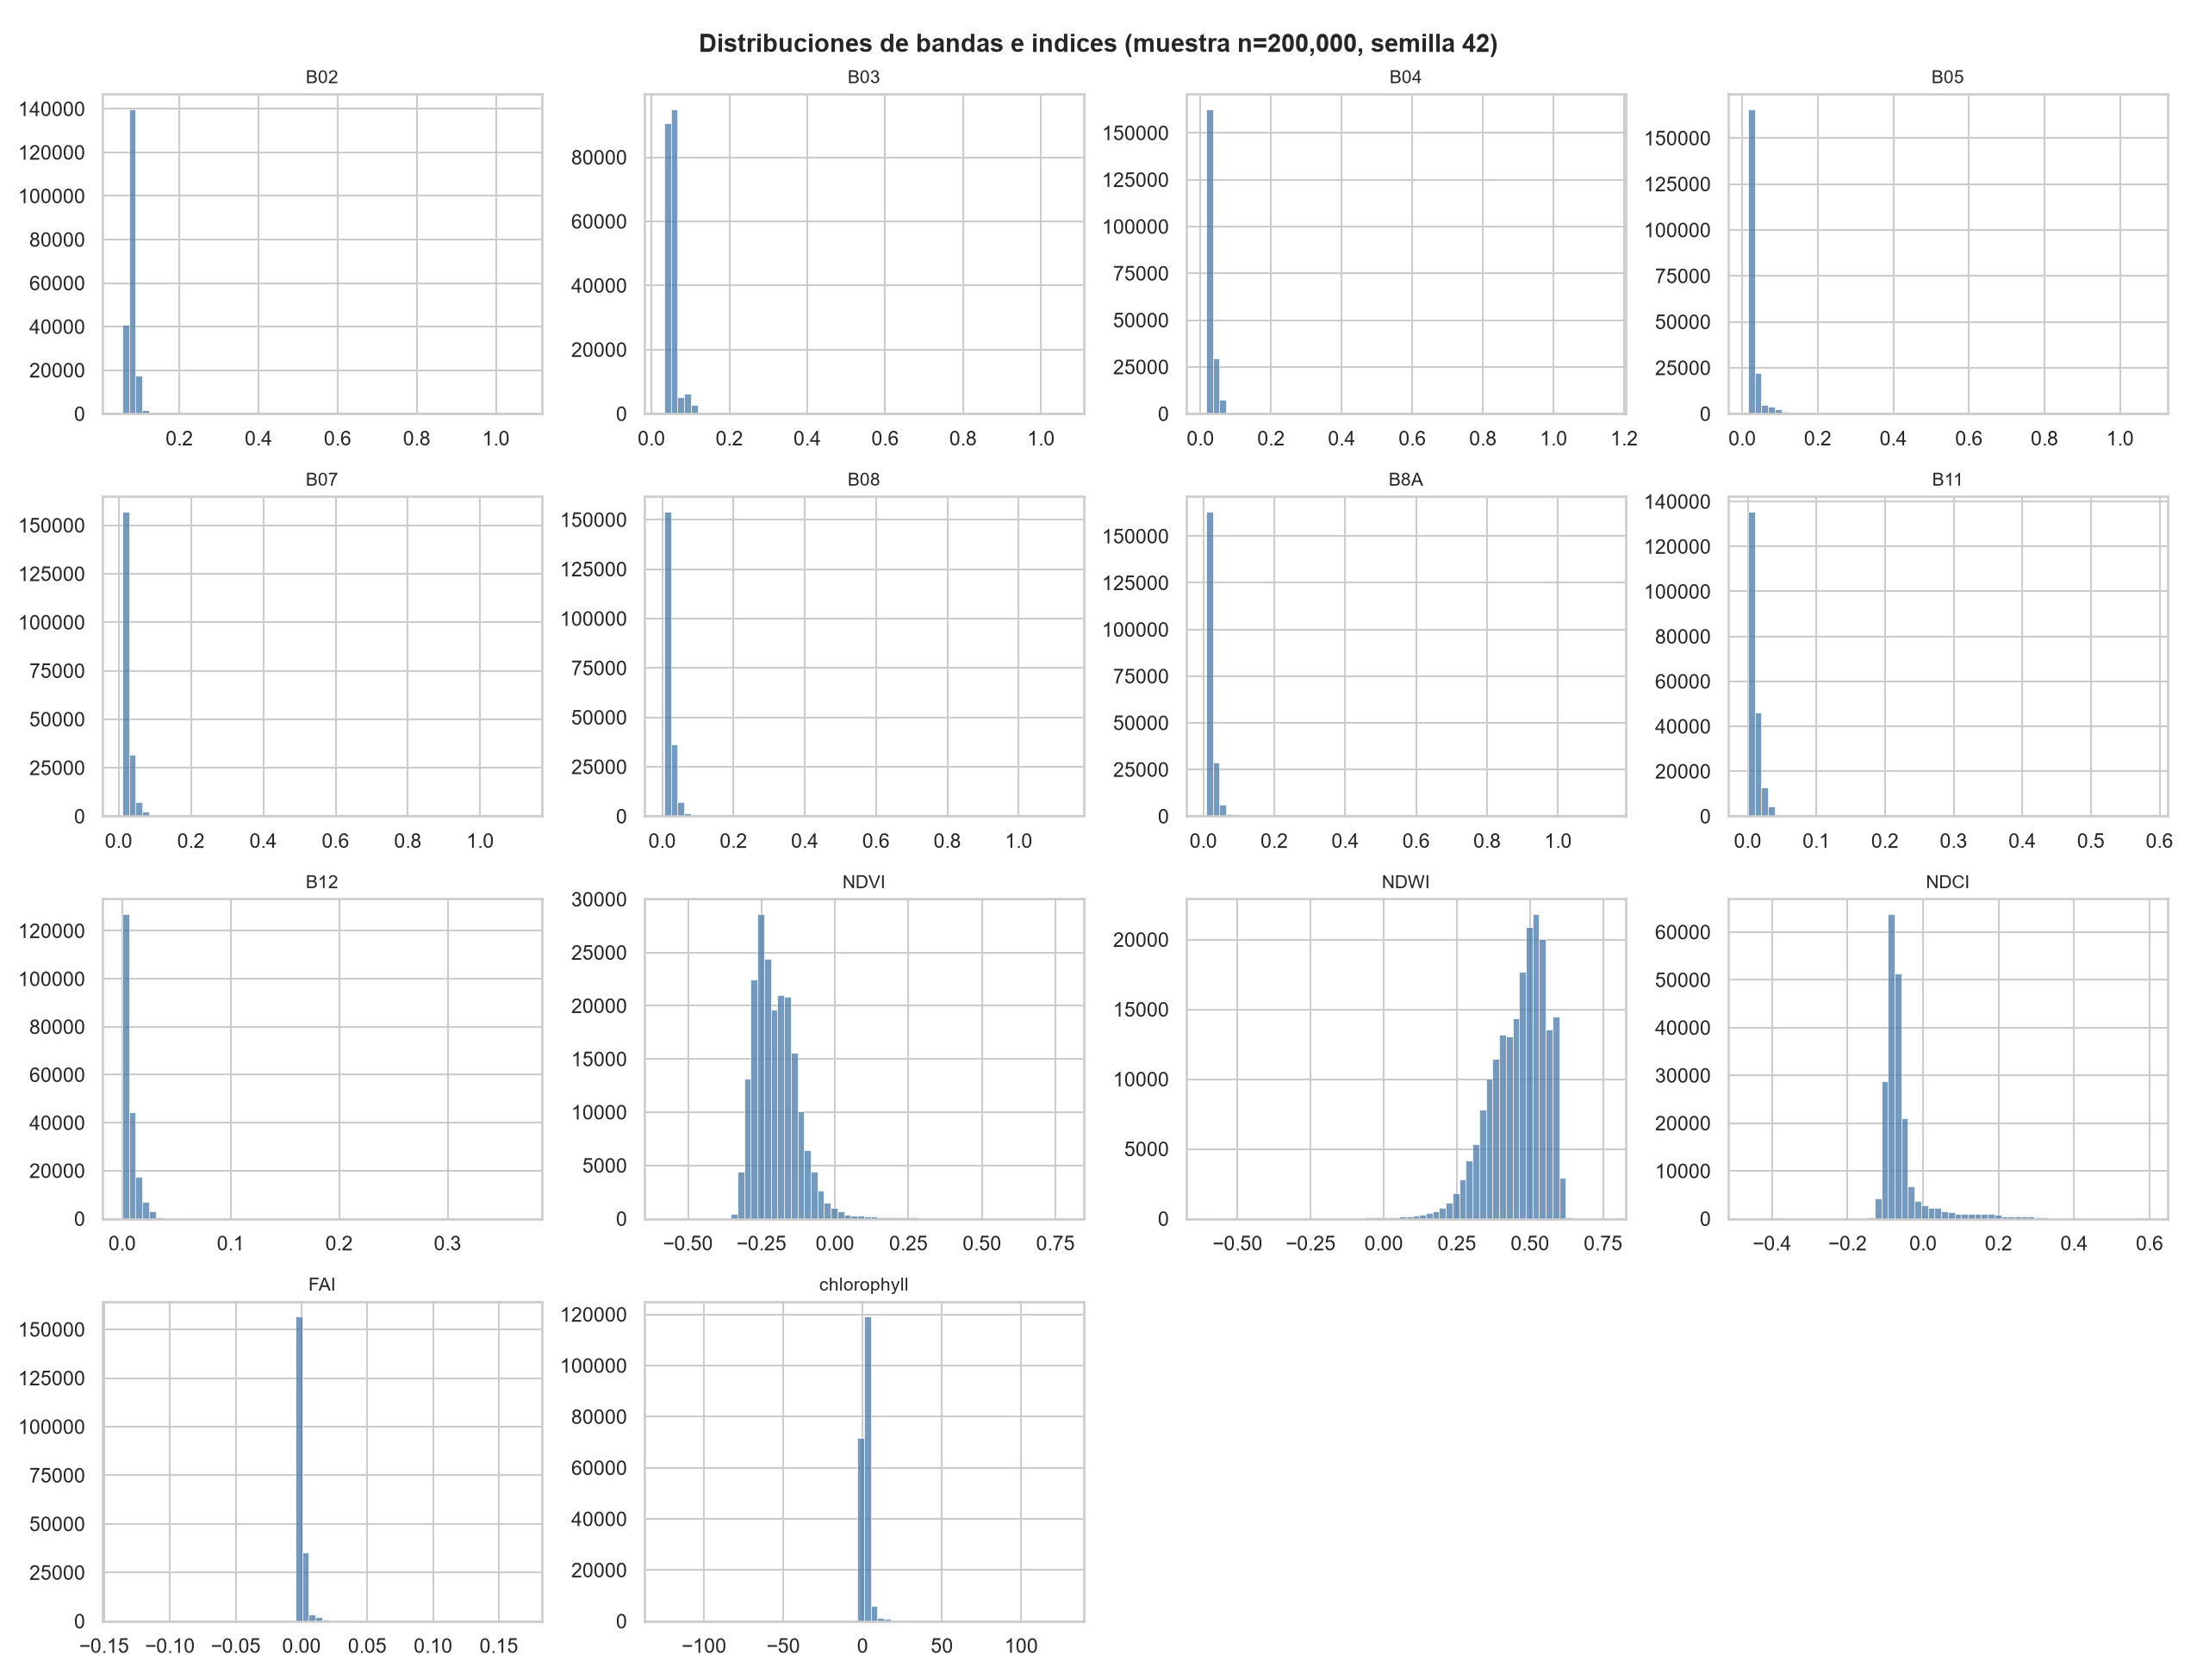

In [7]:
display(Image(filename=str(EDA / "observations_by_lake_date.png")))
display(Image(filename=str(EDA / "feature_distributions.png")))

Distribución de la clorofila-a estimada (dataset completo):
  n                   : 3,756,510
  min                 : -291.1101
  p01                 : -1.8596
  mediana             : 1.3092
  p99                 : 11.3137
  max                 : 135.8611
  negativos           : 560,214
  fuera_calibracion   : 1,513,792

ADVERTENCIA de dominio de calibración [1.0, 60.0] µg/L:
  Fuera de calibración: 1,513,792 (40.30 %)
  Valores negativos   : 560,214 (14.91 %)


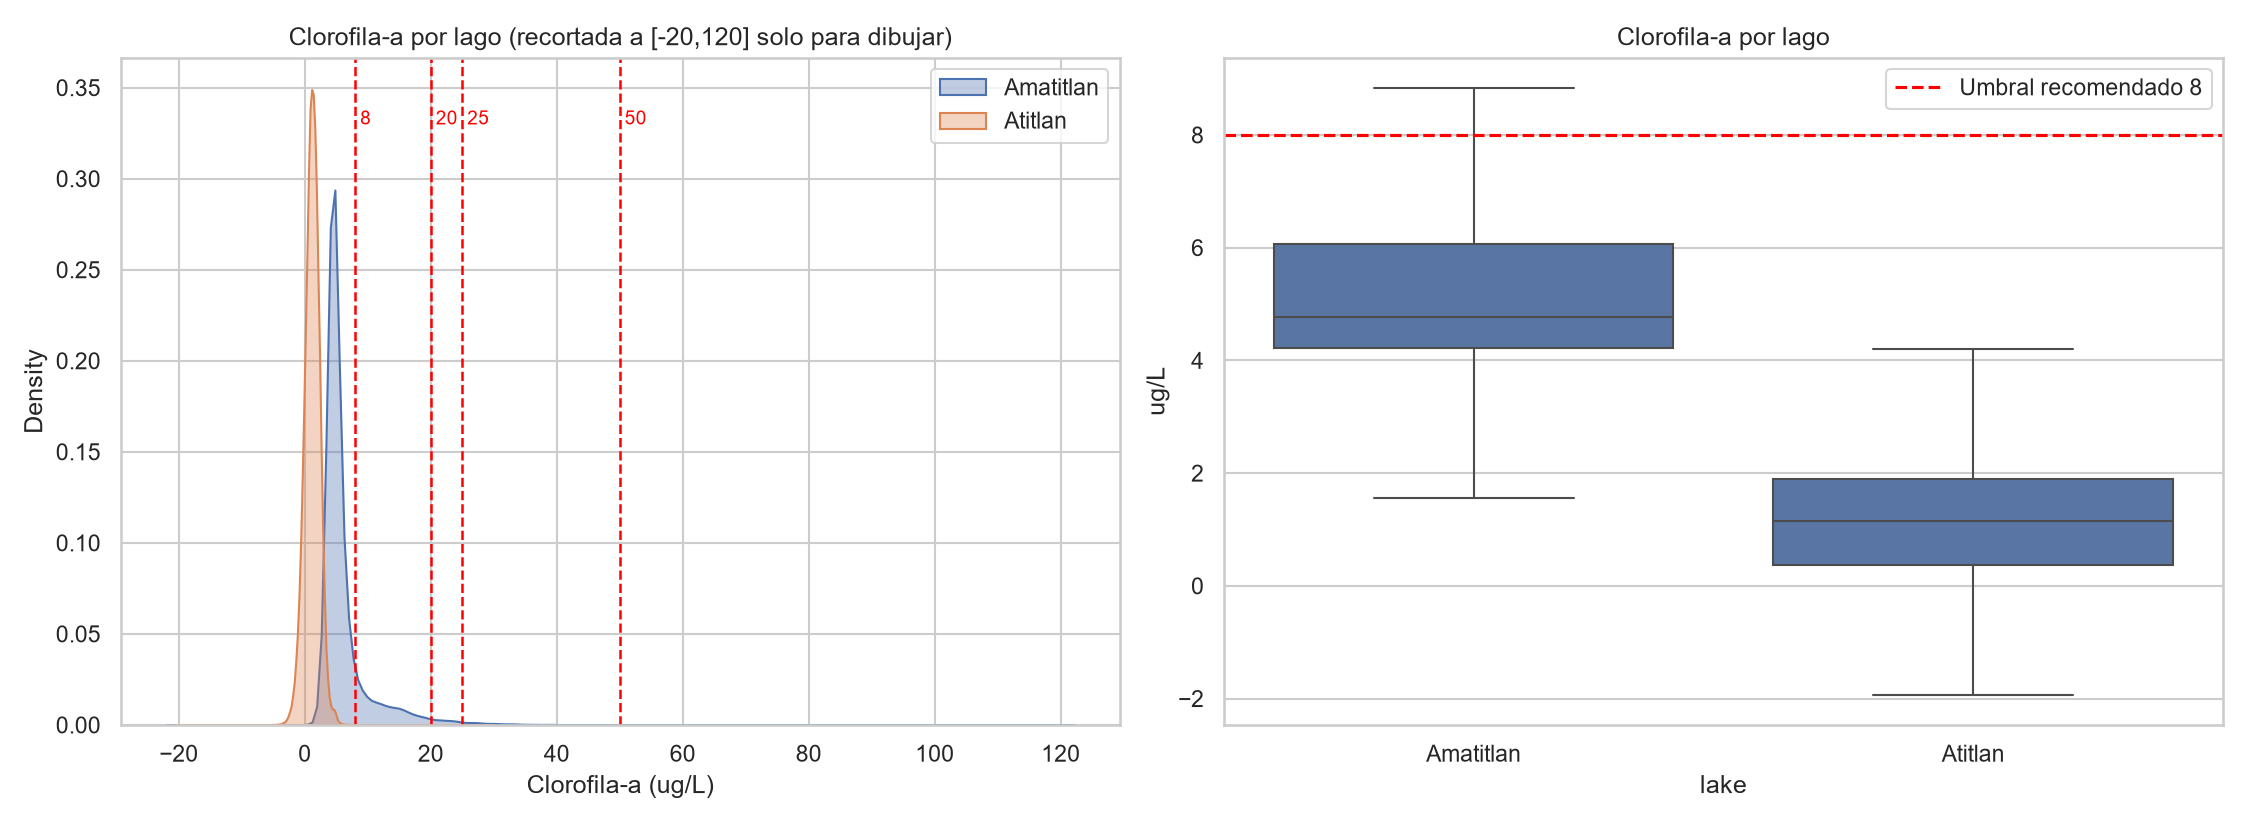

In [8]:
chl_stats = json.load(open(TARGET / "chlorophyll_stats.json", encoding="utf-8"))
print("Distribución de la clorofila-a estimada (dataset completo):")
for k, v in chl_stats.items():
    print(f"  {k:<20}: {v:,.4f}" if isinstance(v, float) else f"  {k:<20}: {v:,}")

print(f"\nADVERTENCIA de dominio de calibración [{CALIB_MIN}, {CALIB_MAX}] µg/L:")
print(f"  Fuera de calibración: {chl_stats['fuera_calibracion']:,} "
      f"({100*chl_stats['fuera_calibracion']/chl_stats['n']:.2f} %)")
print(f"  Valores negativos   : {chl_stats['negativos']:,} "
      f"({100*chl_stats['negativos']/chl_stats['n']:.2f} %)")
display(Image(filename=str(EDA / "chlorophyll_distribution.png")))

> **Los valores negativos de clorofila-a no son concentraciones físicas.** Proceden de
> evaluar el polinomio NDCI → clorofila con NDCI negativo, fuera de su dominio. **No se
> recortaron ni se convirtieron en cero** dentro del dato original: se conservan para
> trazabilidad y se marcan con la columna `fuera_calibracion`, de modo que puedan
> excluirse en cualquier análisis sin alterar el dataset.


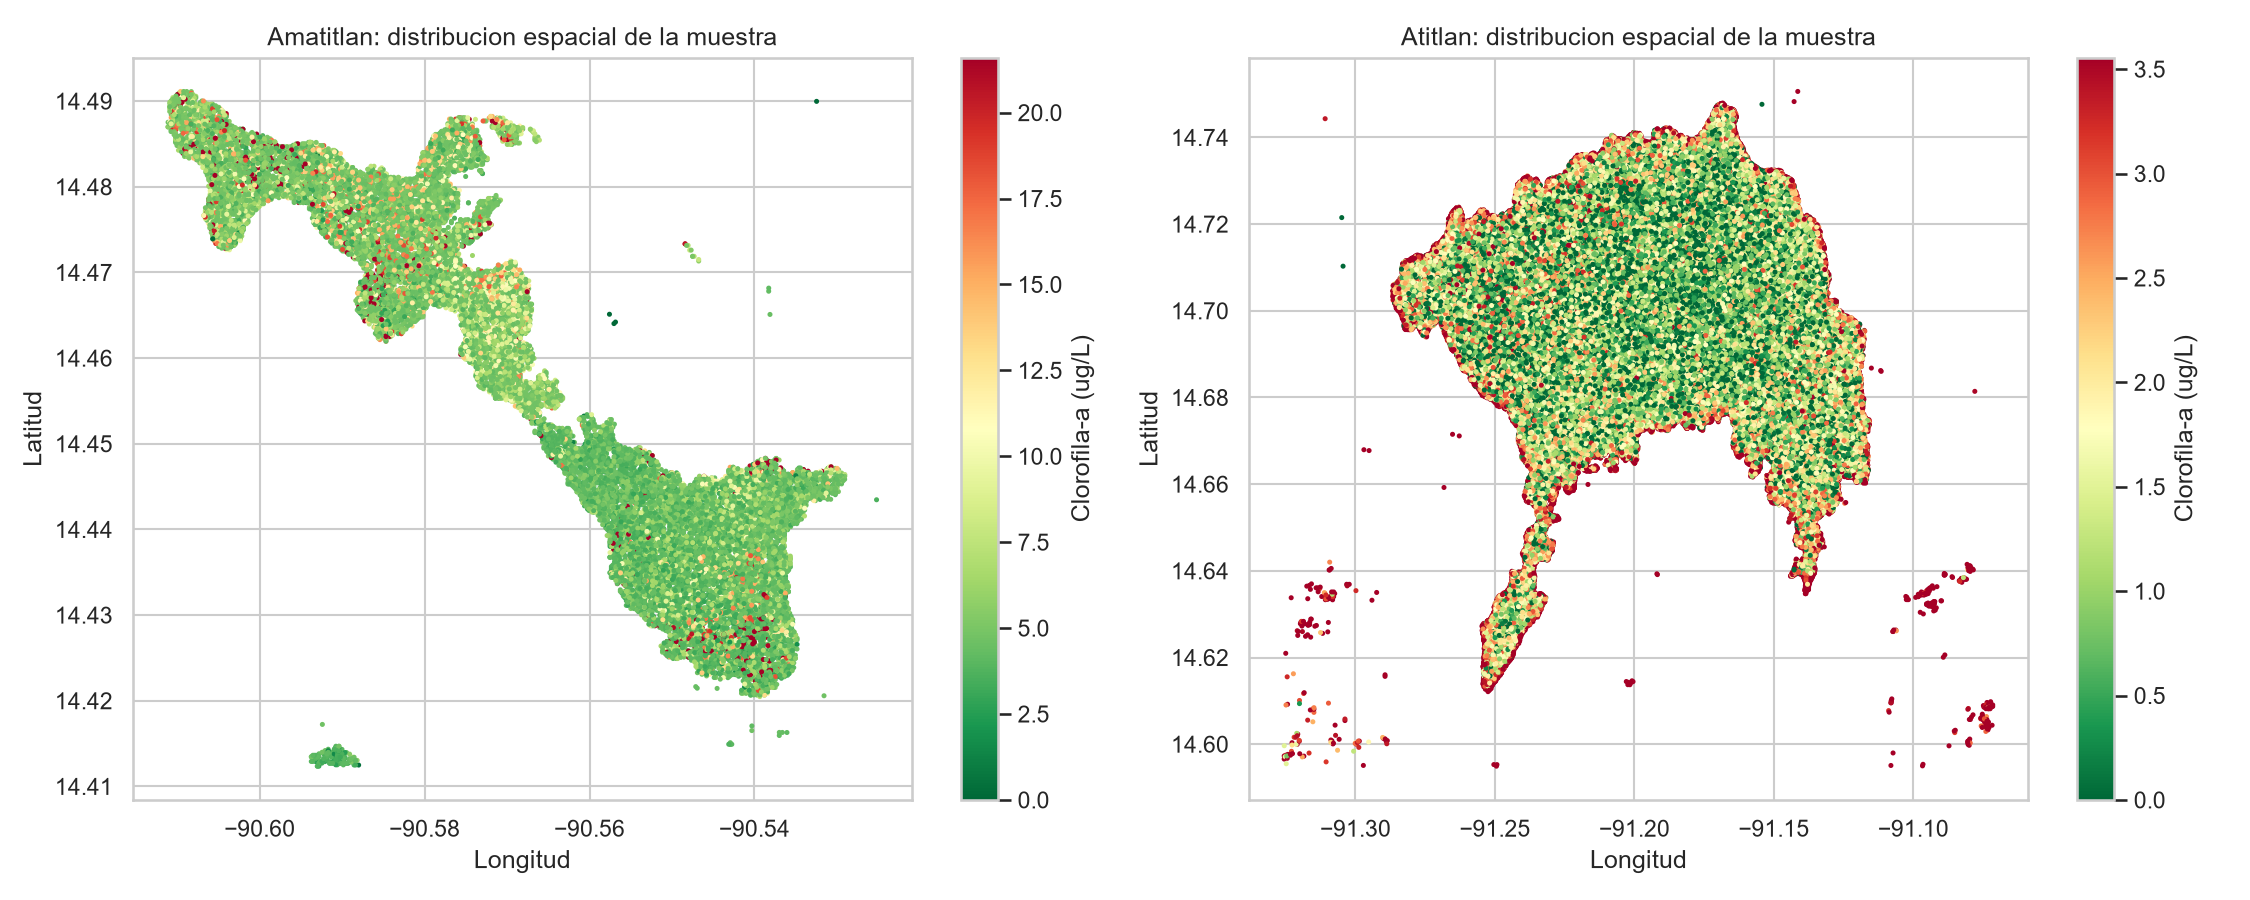

Clorofila-a por lago (muestra determinista):


C:\Users\mjyee\AppData\Local\Temp\ipykernel_19308\4101735042.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(muestra.groupby("lake")["chlorophyll"].describe(


,count,mean,std,min,50%,90%,99%,max
lake,,,,,,,,
Amatitlan,21403.0,6.329,5.332,-19.854,4.762,10.753,26.761,126.830
Atitlan,178597.0,1.114,1.368,-125.095,1.144,2.568,4.130,29.513


In [9]:
# Comparación entre lagos y distribución espacial de la muestra
display(Image(filename=str(EDA / "spatial_sample.png")))
print("Clorofila-a por lago (muestra determinista):")
display(muestra.groupby("lake")["chlorophyll"].describe(
    percentiles=[.5, .9, .99]).round(3))

## 1.6 Decisiones tomadas durante la preparación

| Decisión | Justificación |
|---|---|
| **Escala aplicada una sola vez** | La colección declara `scale = 0.0001, offset = 0`. Se verifica la magnitud antes de transformar, para no dividir dos veces |
| **Una fila por píxel de agua** | El enunciado pide una observación geográfica válida dentro del lago |
| **No se imputan faltantes** | Un píxel sin señal física válida es menos defendible imputado que excluido |
| **Se conservan coordenadas** | Necesarias para reconstrucción espacial y validación agrupada, pero **no como predictores** |
| **Parquet particionado** | 3.75 millones de filas no caben cómodamente en Excel ni en memoria; el particionado por lago y fecha permite leer solo lo necesario |
| **Muestra determinista para figuras** | Semilla 42, reproducible; los conteos siguen calculándose sobre el total |
| **Valores fuera de calibración conservados** | Se marcan, no se eliminan ni se recortan |


---

# Ejercicio 2. Construcción de la variable respuesta

## 2.1 Definición binaria

```
high_cyano_8 = 1  si  clorofila-a >= 8 µg/L
high_cyano_8 = 0  en otro caso
```

> **Prudencia en la interpretación.** La respuesta indica **clorofila-a alta estimada por
> satélite**, no una confirmación in situ de presencia de cianobacterias ni de toxicidad.
> La clorofila mide biomasa fotosintética total: no identifica especies ni toxinas.


## 2.2 Justificación del punto de corte

Se adopta **8 µg/L** porque representa la **transición aproximada hacia la condición
eutrófica**: es la frontera mesotrófico → eutrófico de la clasificación trófica de la
**OECD (1982)**. Operacionaliza «alta presencia» como el punto en que la biomasa algal
deja de ser la propia de un lago equilibrado y el cuerpo de agua entra en un régimen de
exceso de nutrientes.

Los otros tres umbrales **no son alternativas equivalentes**: describen situaciones
ambientales distintas y se conservan como **análisis de sensibilidad**.

| Umbral | Significado ambiental |
|---|---|
| **8 µg/L** *(principal)* | Transición a condición **eutrófica** (OECD 1982) |
| 20 µg/L | **Continuidad con la Parte 1**; dentro de la banda eutrófica (8–25) y del rango de Alerta 1 de la OMS (12–24) |
| 25 µg/L | Transición a condición **hipertrófica** (OECD 1982); coincide con el techo de la Alerta 1 de la OMS (24 µg/L) |
| 50 µg/L | **Escenario extremo**; no aparece como valor de clorofila-a en OECD 1982 ni en las guías de la OMS 2021 |

**El criterio de selección es ambiental.** Que 8 µg/L produzca además más observaciones
positivas es una **consecuencia secundaria** de haber escogido la transición eutrófica, no
el motivo de la elección: la viabilidad estadística se analiza por separado y no
intervino en la definición del umbral.

### Referencias verificadas

- **OECD (1982).** *Eutrophication of Waters: Monitoring, Assessment and Control.* París.
  DOI 10.1787/9789264077980-en. Clasificación por clorofila-a media: oligotrófico < 2.5;
  **mesotrófico 2.5–8**; **eutrófico 8–25**; hipertrófico > 25 µg/L.
- **WHO (2021).** *Guidelines on recreational water quality. Volume 1.* Ginebra. Con
  dominancia de cianobacterias: vigilancia 1–12 µg/L; **Alerta 1: 12–24 µg/L**.
- **Mishra, S. & Mishra, D. R. (2012).** *Normalized difference chlorophyll index…*
  Remote Sensing of Environment **117**, 394–406. DOI 10.1016/j.rse.2011.10.016.
  Introduce el NDCI; calibrado en el rango 1–60 mg/m³.

> **Corrección.** La versión anterior de este cuaderno citaba «Mishra, S. et al. (2019),
> *Applicability of Sentinel-2…*, RSE 232, 111354». Ese DOI corresponde en realidad a
> Hurskainen et al. (2019), *Auxiliary datasets improve accuracy of object-based land
> use/land cover classification in heterogeneous savanna landscapes*, RSE **233**, 111354
> — un artículo de cobertura del suelo, sin relación con calidad del agua. La referencia
> fue sustituida por Mishra & Mishra (2012), que sí sustenta el índice empleado.


## 2.3 Distribución de la respuesta: global, por lago y por fecha

In [10]:
via_global = pd.read_csv(TARGET / "threshold_viability_global.csv")
via_lago = pd.read_csv(TARGET / "threshold_viability_by_lake.csv")
via_fecha = pd.read_csv(TARGET / "threshold_viability_by_date.csv")

print("=== GLOBAL: los cuatro umbrales ===")
display(via_global[["umbral_ug_L", "es_respuesta_principal", "positivos", "negativos",
                    "pct_positivo", "razon_desbalance"]].round(4))

print("=== POR LAGO ===")
display(via_lago[["umbral_ug_L", "lake", "positivos", "negativos",
                  "pct_positivo"]].round(4))

print(f"=== POR FECHA (respuesta principal {TARGET_THRESHOLD_UG_L:.0f} µg/L) ===")
display(via_fecha[via_fecha["umbral_ug_L"] == TARGET_THRESHOLD_UG_L][
    ["lake", "date", "n_total", "positivos", "negativos", "pct_positivo",
     "ambas_clases"]].round(4))

=== GLOBAL: los cuatro umbrales ===


,umbral_ug_L,es_respuesta_principal,positivos,negativos,pct_positivo,razon_desbalance
0,8.0,True,60146,3696364,1.6011,61.4565
1,20.0,False,9832,3746678,0.2617,381.0698
2,25.0,False,5195,3751315,0.1383,722.1011
3,50.0,False,608,3755902,0.0162,6177.4704


=== POR LAGO ===


,umbral_ug_L,lake,positivos,negativos,pct_positivo
0,8.0,Amatitlan,57996,341650,14.5118
1,8.0,Atitlan,2150,3354714,0.0640
2,20.0,Amatitlan,9768,389878,2.4442
3,20.0,Atitlan,64,3356800,0.0019
4,25.0,Amatitlan,5181,394465,1.2964
5,25.0,Atitlan,14,3356850,0.0004
6,50.0,Amatitlan,604,399042,0.1511
7,50.0,Atitlan,4,3356860,0.0001


=== POR FECHA (respuesta principal 8 µg/L) ===


,lake,date,n_total,positivos,negativos,pct_positivo,ambas_clases
0,Amatitlan,2025-01-28,36550,44,36506,0.1204,True
1,Amatitlan,2025-04-15,36184,739,35445,2.0423,True
2,Amatitlan,2025-04-28,36184,4912,31272,13.5751,True
3,Amatitlan,2025-11-24,36434,1029,35405,2.8243,True
4,Amatitlan,2026-01-08,36668,3484,33184,9.5015,True
5,Amatitlan,2026-02-02,36130,6,36124,0.0166,True
6,Amatitlan,2026-02-07,36561,35,36526,0.0957,True
7,Amatitlan,2026-03-29,36594,3906,32688,10.6739,True
8,Amatitlan,2026-04-13,36786,5599,31187,15.2205,True
9,Amatitlan,2026-04-28,34911,15186,19725,43.4992,True


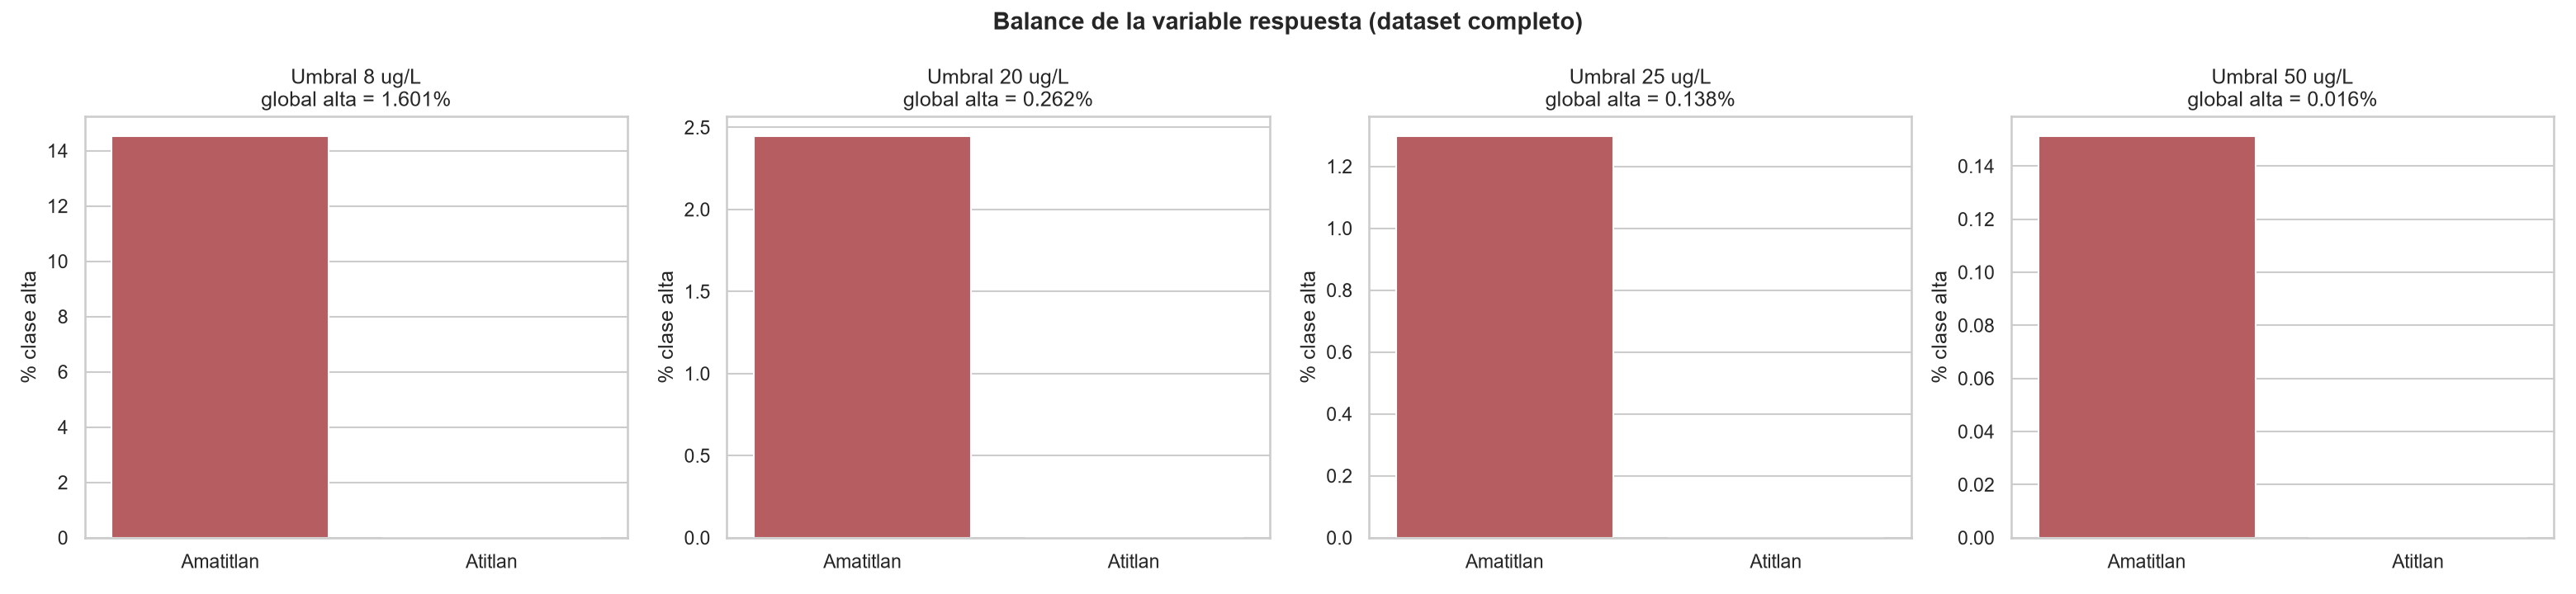

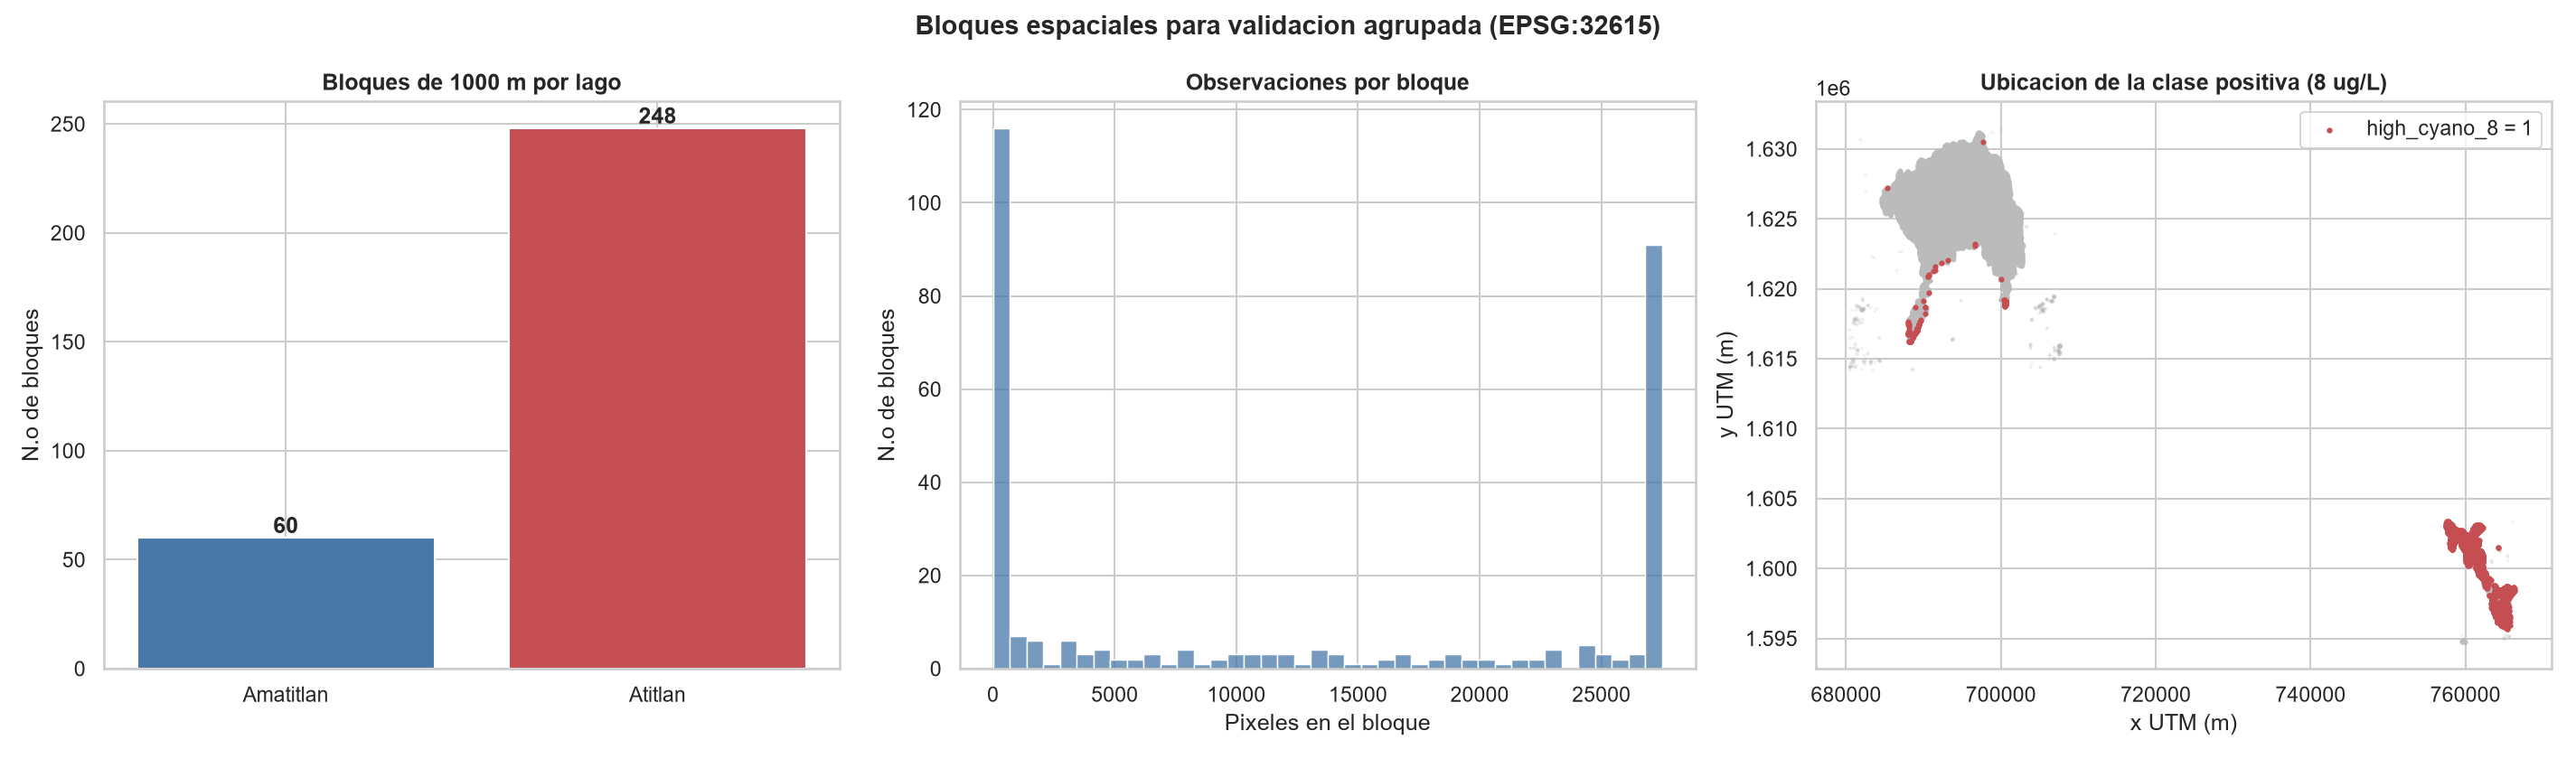

In [11]:
display(Image(filename=str(EDA / "target_balance.png")))
display(Image(filename=str(EDA / "spatial_blocks.png")))

## 2.4 Desbalance de clases y sus consecuencias

In [12]:
principal = via_global[via_global["umbral_ug_L"] == TARGET_THRESHOLD_UG_L].iloc[0]
print(f"RESPUESTA PRINCIPAL: {TARGET_COLUMN} (>= {TARGET_THRESHOLD_UG_L:.0f} µg/L)\n")
print(f"  Positivos : {int(principal['positivos']):,} ({principal['pct_positivo']:.3f} %)")
print(f"  Negativos : {int(principal['negativos']):,}")
print(f"  Desbalance: 1 : {principal['razon_desbalance']:.0f}\n")
print(f"  Fechas con ambas clases : {int(principal['fechas_con_ambas_clases'])}/22")
print(f"  Bloques con positivos   : {int(principal['bloques_con_positivos'])}"
      f"/{int(principal['bloques_totales'])}")
print(f"  N.º efectivo de bloques : {principal['n_efectivo_bloques_positivos']:.1f}")
print(f"  Positivos en 5 bloques  : {principal['pct_positivos_en_top5_bloques']:.1f} %")

acc_trivial = 100 - principal["pct_positivo"]
print(f"\nRIESGO: un clasificador que prediga SIEMPRE la clase mayoritaria")
print(f"        obtendría {acc_trivial:.3f} % de Accuracy sin detectar")
print(f"        ni una sola floración.")

RESPUESTA PRINCIPAL: high_cyano_8 (>= 8 µg/L)

  Positivos : 60,146 (1.601 %)
  Negativos : 3,696,364
  Desbalance: 1 : 61

  Fechas con ambas clases : 22/22
  Bloques con positivos   : 120/308
  N.º efectivo de bloques : 20.5
  Positivos en 5 bloques  : 37.7 %

RIESGO: un clasificador que prediga SIEMPRE la clase mayoritaria
        obtendría 98.399 % de Accuracy sin detectar
        ni una sola floración.


### Consecuencias sobre entrenamiento y evaluación

- **Accuracy engañosa.** Con esta prevalencia, predecir siempre «no hay floración» da una
  exactitud altísima y utilidad nula.
- **Diferencia entre lagos.** Amatitlán tiene una prevalencia ~226 veces mayor que
  Atitlán. Un modelo entrenado en uno verá una frecuencia de clase muy distinta en el otro.
- **Dependencia espacial.** Buena parte de los positivos se concentra en unos pocos
  bloques de 1 km: **no son observaciones independientes**. Sin agrupar por bloque,
  píxeles vecinos casi idénticos caerían a la vez en entrenamiento y prueba, inflando el
  desempeño.
- **Riesgo de folds sin positivos** en validación cruzada agrupada.
- **Colapso a la clase mayoritaria** durante el entrenamiento si no se compensa.

### Recomendaciones para el Ejercicio 4 *(no implementadas todavía)*

- `class_weight="balanced"` en Regresión Logística y Random Forest.
- `scale_pos_weight = n_negativos / n_positivos` en XGBoost.
- Reportar **PR-AUC** además de las métricas obligatorias: con esta prevalencia la curva
  ROC resulta demasiado optimista.
- Reportar **Recall y F1 de la clase positiva** por separado, no solo macro.
- Ajustar el **umbral de decisión** usando solo entrenamiento/validación, nunca prueba.
- **No aplicar SMOTE ni sobremuestreo antes de separar los grupos**: generaría vecinos
  sintéticos de píxeles que después caerían en prueba.
- Conservar intactos los grupos espaciales (`spatial_block_1km`) y temporales (`date`).


### Viabilidad estadística de cada umbral

Un umbral **no** se declara viable por tener un píxel positivo. Los criterios aplicados
son explícitos: ambas clases presentes, positivos repartidos en varias fechas y bloques,
y suficientes grupos positivos para los 5 folds propuestos.


In [13]:
display(via_global[["umbral_ug_L", "positivos", "pct_positivo",
                    "fechas_con_ambas_clases", "bloques_con_positivos",
                    "n_efectivo_bloques_positivos", "viable_stratified_70_30",
                    "viable_groupkfold_bloque", "viable_validacion_temporal",
                    "entrenable_por_lago", "viable_generalizacion_entre_lagos"]].round(3))

print("\nCLAVE: solo 8 µg/L permite entrenar en AMBOS lagos.")
print("Con 20 y 25 µg/L, Atitlán queda con 64 y 14 positivos respectivamente:")
print("insuficiente para entrenar, aunque sí para evaluar.")
print("Con 50 µg/L ningún lago alcanza el mínimo práctico.")

,umbral_ug_L,positivos,pct_positivo,fechas_con_ambas_clases,bloques_con_positivos,n_efectivo_bloques_positivos,viable_stratified_70_30,viable_groupkfold_bloque,viable_validacion_temporal,entrenable_por_lago,viable_generalizacion_entre_lagos
0,8.0,60146,1.601,22,120,20.475,True,True,True,Amatitlan=True;Atitlan=True,True
1,20.0,9832,0.262,15,53,11.933,True,True,True,Amatitlan=True;Atitlan=False,False
2,25.0,5195,0.138,14,42,9.700,True,True,True,Amatitlan=True;Atitlan=False,False
3,50.0,608,0.016,5,13,5.035,True,True,True,Amatitlan=False;Atitlan=False,False



CLAVE: solo 8 µg/L permite entrenar en AMBOS lagos.
Con 20 y 25 µg/L, Atitlán queda con 64 y 14 positivos respectivamente:
insuficiente para entrenar, aunque sí para evaluar.
Con 50 µg/L ningún lago alcanza el mínimo práctico.


## 2.5 Variables que no pueden usarse como predictoras

La cadena de construcción de la respuesta es:

```
B04, B05  →  NDCI  →  chlorophyll  →  high_cyano_8
```

Cualquier variable que participe en esa cadena, directa o indirectamente, produciría
**fuga de información**.


In [14]:
fuga = pd.DataFrame([
    {"variable": v, "motivo": m} for v, m in EXCLUIDAS_POR_FUGA.items()])
display(fuga)

# Comprobación automática: ninguna prohibida puede estar en el conjunto predictor.
respuestas = [f"high_cyano_{int(u)}" for u in UMBRALES_CANDIDATOS]
prohibidas = set(EXCLUIDAS_POR_FUGA) | set(respuestas) | set(COLUMNAS_AUXILIARES)
intrusas = [c for c in PREDICTORES_PRINCIPALES if c in prohibidas]
assert not intrusas, f"FUGA DE INFORMACIÓN: {intrusas}"
print(f"\nVerificado: ninguno de los {len(PREDICTORES_PRINCIPALES)} predictores")
print("principales pertenece a la cadena de la respuesta.")

,variable,motivo
0,B04,"insumo directo de NDCI, que genera la clorofil..."
1,B05,"insumo directo de NDCI, que genera la clorofil..."
2,NDCI,indice del que se deriva la clorofila y por ta...
3,chlorophyll,variable de la que se deriva directamente la r...
4,FAI,utiliza B04; comparte insumo con NDCI (fuga in...
5,NDVI,utiliza B04; se conserva porque el enunciado l...
6,high_cyano_8,es la propia respuesta principal
7,high_cyano_20,es una respuesta candidata (sensibilidad)
8,high_cyano_25,es una respuesta candidata (sensibilidad)
9,high_cyano_50,es una respuesta candidata (sensibilidad)



Verificado: ninguno de los 8 predictores
principales pertenece a la cadena de la respuesta.


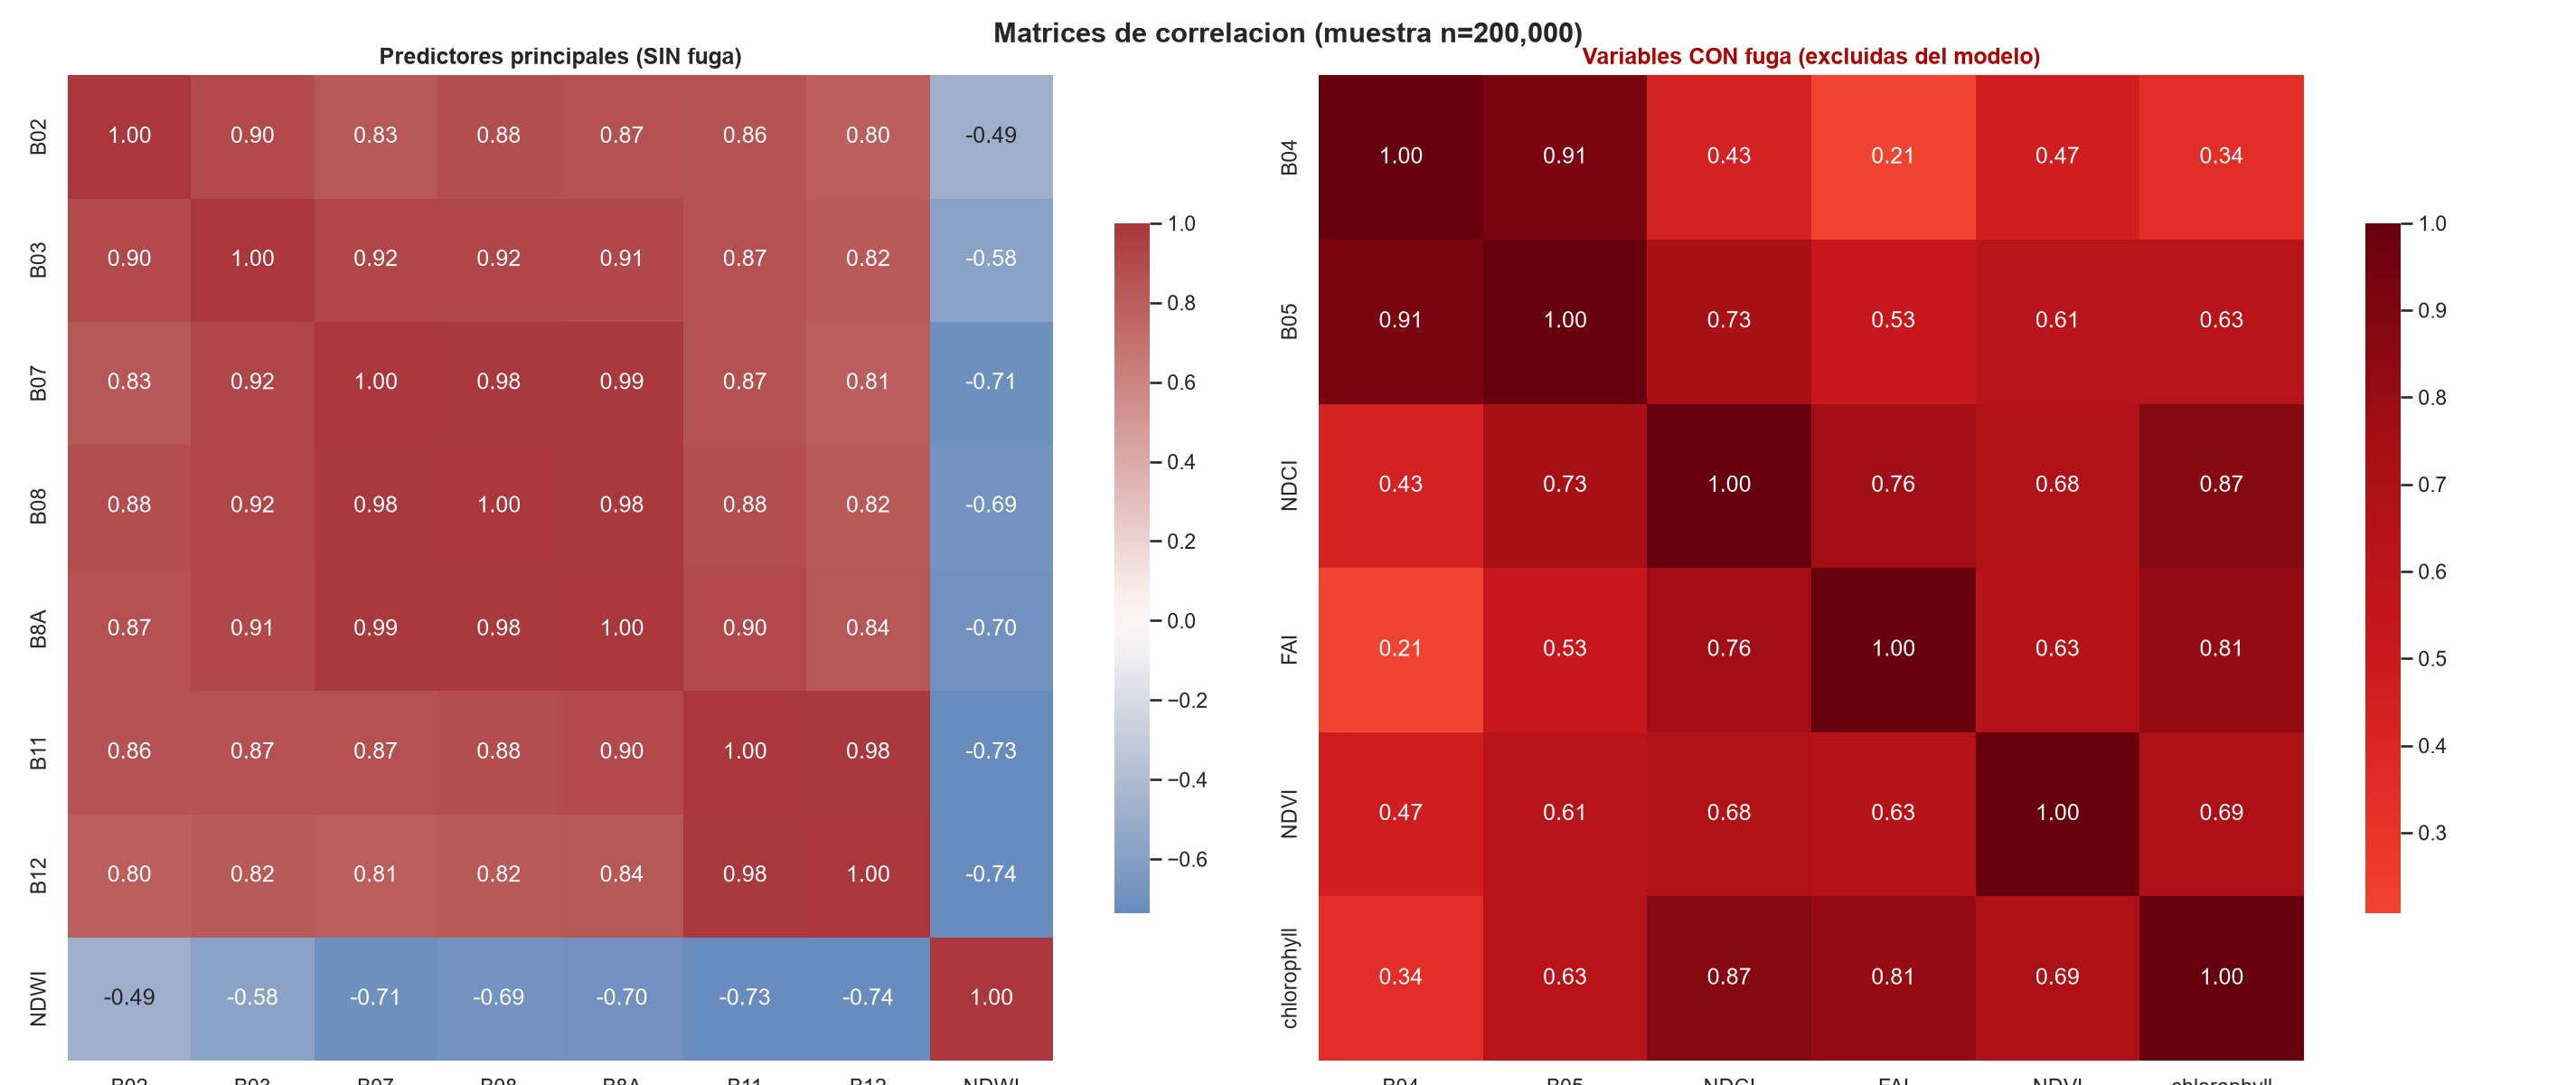

In [15]:
display(Image(filename=str(EDA / "correlation_matrix.png")))

La matriz de la derecha muestra las variables **con fuga**, separadas
visualmente de los predictores permitidos. La correlación entre `NDCI` y `chlorophyll` es
altísima por construcción —la segunda se calcula a partir de la primera— y por eso
**ninguna de las dos puede usarse como predictor**.


---

# Ejercicio 3. Selección y construcción de variables predictoras

## 3.1 Conjunto predictor principal


In [16]:
print("PREDICTORES PRINCIPALES (sin fuga):")
for p in PREDICTORES_PRINCIPALES:
    print(f"  - {p}")
print(f"\nTotal: {len(PREDICTORES_PRINCIPALES)} variables")

print("\nEstadísticas (muestra determinista):")
display(muestra[PREDICTORES_PRINCIPALES].describe(percentiles=[.05, .5, .95]).T.round(4))

PREDICTORES PRINCIPALES (sin fuga):
  - B02
  - B03
  - B07
  - B08
  - B8A
  - B11
  - B12
  - NDWI

Total: 8 variables

Estadísticas (muestra determinista):


,count,mean,std,min,5%,50%,95%,max
B02,200000.0,0.0795,0.0131,0.0558,0.0700,0.0781,0.0925,1.0656
B03,200000.0,0.0535,0.0156,0.0327,0.0436,0.0504,0.0815,1.0586
B07,200000.0,0.0249,0.0170,0.0101,0.0141,0.0212,0.0491,1.1154
B08,200000.0,0.0212,0.0162,0.0057,0.0115,0.0179,0.0426,1.1267
B8A,200000.0,0.0207,0.0158,0.0078,0.0104,0.0174,0.0424,1.1344
B11,200000.0,0.0093,0.0094,0.0005,0.0018,0.0068,0.0249,0.5827
B12,200000.0,0.0066,0.0070,0.0001,0.0010,0.0044,0.0193,0.3685
NDWI,200000.0,0.4589,0.1000,-0.6075,0.2865,0.4780,0.5868,0.7590


## 3.2 Qué representa cada predictor y por qué puede ayudar

| Variable | Tipo | Qué representa y por qué contribuye |
|---|---|---|
| **B02** | Banda espectral (azul, 492 nm) | Sensible a la dispersión por partículas y a la turbidez del agua |
| **B03** | Banda espectral (verde, 560 nm) | Máximo de reflectancia de la biomasa algal: el agua con algas se ve más verde. **No interviene en el NDCI** |
| **B07** | Banda espectral (borde rojo, 783 nm) | Responde a la biomasa vegetal en el agua sin usar B04 ni B05 |
| **B08** | Banda espectral (NIR, 833 nm) | Separa agua de vegetación y detecta natas flotantes en superficie |
| **B8A** | Banda espectral (NIR estrecho, 865 nm) | Complementa a B08 con menor influencia del vapor de agua |
| **B11** | Banda espectral (SWIR1, 1610 nm) | Distingue agua de suelo y de nube; el agua absorbe casi toda la radiación SWIR |
| **B12** | Banda espectral (SWIR2, 2190 nm) | Refuerza la discriminación de agua y detecta contaminación por píxeles mixtos |
| **NDWI** | Índice espectral | (B03 − B08)/(B03 + B08). Caracteriza el estado de la lámina de agua. **No usa B04 ni B05**, así que es independiente de la cadena de la respuesta |

Todos son **bandas espectrales o índices**, no características espaciales: la decisión es
deliberada, para que el modelo aprenda una **señal espectral generalizable** y no la
geografía concreta de estos dos lagos.


## 3.3 Ingeniería de características y variables de agrupación

### Ingeniería propuesta para más adelante *(no aplicada todavía)*

Estas variables podrían construirse en el Ejercicio 4, siempre a partir de bandas
**permitidas**:

- **`rededge_mean` = media de B07 y B8A** — resume la respuesta del borde rojo asociada a
  biomasa, sin tocar B04 ni B05.
- **`nir_green_ratio` = B08 / B03** — contraste entre infrarrojo y verde; sensible a
  material particulado en suspensión.

No se añaden ahora para mantener el conjunto base auditable y comprobar primero el
desempeño de las variables originales.

### Análisis de sensibilidad con NDVI *(etiquetado como riesgo)*

`NDVI` se **conserva en el dataset** porque el enunciado lo exige explícitamente, pero
**no entra en el modelo principal**: usa **B04**, el mismo canal que alimenta el NDCI del
que se deriva la respuesta. Queda preparado como comparación secundaria, claramente
marcada como **riesgo de fuga indirecta**. Si en esa comparación el NDVI apareciera como
variable dominante, sería señal de fuga residual y no de señal ecológica genuina.

### Variables auxiliares de agrupación *(no predictoras)*

| Variable | Uso previsto |
|---|---|
| `spatial_block_1km` | Grupos para `GroupKFold` espacial (Ejercicio 6) |
| `date`, `year`, `month`, `season` | Validación temporal (Ejercicio 6) |
| `lake` | Generalización entre lagos (Ejercicio 7) |
| `row`, `col`, `x_utm`, `y_utm`, `longitude`, `latitude` | Reconstrucción de mapas predictivos (Ejercicio 9) |

Se conservan para agrupar, estratificar y reconstruir, pero **incluirlas como predictores
haría que el modelo memorizara la posición y la fecha** en lugar de aprender el fenómeno.


In [17]:
bloques = pd.read_csv(DATA / "resumen_bloques_1km.csv")
print(f"Bloques espaciales de {BLOQUE_ESPACIAL_M:.0f} m:")
display(bloques.groupby("lake").agg(
    n_bloques=("spatial_block_1km", "nunique"),
    obs_por_bloque_media=("n", "mean"),
    obs_por_bloque_min=("n", "min"),
    obs_por_bloque_max=("n", "max"),
    bloques_con_positivos=("positivos", lambda s: int((s > 0).sum())),
).round(1))

conc = pd.read_csv(TARGET / "threshold_group_concentration.csv")
print("\nConcentración de la clase positiva:")
display(conc[["umbral_ug_L", "positivos_totales", "pct_positivos_en_top5_fechas",
              "pct_positivos_en_top5_bloques", "bloques_positivos",
              "n_efectivo_bloques_positivos"]].round(2))

Bloques espaciales de 1000 m:


,n_bloques,obs_por_bloque_media,obs_por_bloque_min,obs_por_bloque_max,bloques_con_positivos
lake,,,,,
Amatitlan,60,6660.8,1,27498,38
Atitlan,248,13535.7,1,27500,82



Concentración de la clase positiva:


,umbral_ug_L,positivos_totales,pct_positivos_en_top5_fechas,pct_positivos_en_top5_bloques,bloques_positivos,n_efectivo_bloques_positivos
0,8.0,60146,87.55,37.70,120,20.48
1,20.0,9832,96.85,54.38,53,11.93
2,25.0,5195,98.25,57.98,42,9.70
3,50.0,608,100.00,86.18,13,5.03


---

# Ejercicio 4. Construcción de modelos de Machine Learning

Los modelos se entrenaron con `modelos_parte2.py` (~80 minutos). **Este cuaderno no
reentrena nada**: carga los resultados ya guardados en `outputs/parte2/`.

```
python modelos_parte2.py --all --profile standard --n-jobs 8
```


In [18]:
MET = P2 / "metrics"
FIG = P2 / "figures"
TUN = P2 / "tuning"
SPL = P2 / "splits"

split = json.loads((SPL / "split_70_30.json").read_text(encoding="utf-8"))
print("EJERCICIO 4.2 — División 70/30 estratificada")
print(f"  Entrenamiento : {split['n_train']:,} filas | {split['positivos_train']:,} positivos "
      f"({100*split['prevalencia_train']:.4f} %)")
print(f"  Prueba        : {split['n_test']:,} filas | {split['positivos_test']:,} positivos "
      f"({100*split['prevalencia_test']:.4f} %)")
print(f"  Firma del test: {split['test_hash']}")
print(f"  Modelos que usaron ESE MISMO test: {split['modelos_que_usaron_este_test']}")
print(f"  Semilla: {split['semilla']} | estratificado por: {split['estratificado_por']}")
print("\n  El test conserva la prevalencia natural: no se balanceó ni se submuestreó,")
print("  y no intervino en el tuning ni en la elección del umbral.")

EJERCICIO 4.2 — División 70/30 estratificada
  Entrenamiento : 2,629,557 filas | 42,102 positivos (1.6011 %)
  Prueba        : 1,126,953 filas | 18,044 positivos (1.6011 %)
  Firma del test: 67bc81d40aad20b0
  Modelos que usaron ESE MISMO test: ['logistic']
  Semilla: 42 | estratificado por: high_cyano_8

  El test conserva la prevalencia natural: no se balanceó ni se submuestreó,
  y no intervino en el tuning ni en la elección del umbral.


In [19]:
print("EJERCICIO 4.3 — Ajuste de hiperparámetros\n")
filas = []
for m in ["logistic", "random_forest", "xgboost"]:
    t = json.loads((TUN / f"tuning_{m}_standard.json").read_text(encoding="utf-8"))
    filas.append({"modelo": m, "configuraciones": t["n_configuraciones"],
                  "folds": t["folds"], "metrica": t["metrica_seleccion"],
                  "PR_AUC_tuning": round(t["mejor_score"], 4),
                  "segundos": round(t["segundos"], 1),
                  "mejores_hiperparametros": str(t["mejores_parametros"])})
display(pd.DataFrame(filas))

t = json.loads((TUN / "tuning_logistic_standard.json").read_text(encoding="utf-8"))
print(f"Muestra de tuning: {t['muestra_tuning']['n']:,} filas "
      f"({t['muestra_tuning']['estrategia']})")
print(f"Prevalencia en la muestra: {100*t['muestra_tuning']['prevalencia']:.4f} %")
print(f"Origen: {t['origen_muestra']}")

EJERCICIO 4.3 — Ajuste de hiperparámetros



,modelo,configuraciones,folds,metrica,PR_AUC_tuning,segundos,mejores_hiperparametros
0,logistic,12,3,average_precision (PR-AUC),0.9836,337.2,"{'modelo__l1_ratio': 0.0, 'modelo__C': 0.01}"
1,random_forest,12,3,average_precision (PR-AUC),0.9962,263.3,"{'min_samples_leaf': 5, 'max_features': 'sqrt'..."
2,xgboost,12,3,average_precision (PR-AUC),0.9972,120.6,"{'subsample': 0.6, 'min_child_weight': 10, 'ma..."


Muestra de tuning: 400,000 filas (todos los positivos + negativos aleatorios (semilla fija))
Prevalencia en la muestra: 10.5255 %
Origen: exclusivamente del conjunto de entrenamiento


### Reproducibilidad

- **Semilla 42** en el split, el tuning, los tres modelos y la validación.
- El conjunto de prueba tiene **firma `67bc81d40aad20b0`**, idéntica para los tres modelos:
  la comparación es justa por construcción.
- La métrica de selección es **PR-AUC**, nunca Accuracy.

> **Nota sobre Regresión Logística.** El código migró de `penalty` (deprecado en
> scikit-learn 1.8) a `l1_ratio`: `l1_ratio=0` equivale a L2 y `l1_ratio=1` a L1. La
> equivalencia se verificó numéricamente —mismos coeficientes con el mismo `C`, solver y
> semilla— y las métricas resultantes son idénticas.


---

# Ejercicio 5. Evaluación de los modelos


In [20]:
r = pd.read_csv(MET / "random" / "metricas_standard.csv")
cols = ["modelo", "etiqueta", "umbral", "pr_auc", "roc_auc", "recall", "precision",
        "f1", "f2", "mcc", "balanced_accuracy", "specificity", "brier", "accuracy",
        "TP", "FN", "FP", "TN"]
display(r[cols].sort_values(["modelo", "etiqueta"]).round(4))

prev = split["prevalencia_test"]
print(f"Prevalencia real del test: {100*prev:.4f} %")
print(f"Accuracy de un clasificador trivial (siempre clase 0): {100*(1-prev):.3f} %")
print("\nPor eso Accuracy NO es la métrica principal: ese 98.4 % no detecta")
print("ni una sola floración. La métrica de referencia es PR-AUC.")

,modelo,etiqueta,umbral,pr_auc,roc_auc,recall,precision,f1,f2,mcc,balanced_accuracy,specificity,brier,accuracy,TP,FN,FP,TN
4,logistic,umbral_0.5,0.5000,0.9135,0.9979,0.9947,0.4678,0.6364,0.8118,0.6758,0.9882,0.9816,0.0141,0.9818,17949,95,20419,1088490
5,logistic,umbral_operacional,0.9722,0.9135,0.9979,0.8012,0.8852,0.8411,0.8167,0.8397,0.8997,0.9983,0.0141,0.9952,14456,3588,1874,1107035
0,random_forest,umbral_0.5,0.5000,0.9814,0.9996,0.9644,0.8550,0.9064,0.9403,0.9065,0.9809,0.9973,0.0023,0.9968,17401,643,2950,1105959
1,random_forest,umbral_operacional,0.9408,0.9814,0.9996,0.8079,0.9839,0.8873,0.8379,0.8901,0.9038,0.9998,0.0023,0.9967,14578,3466,238,1108671
2,xgboost,umbral_0.5,0.5000,0.9826,0.9997,0.9885,0.7505,0.8532,0.9295,0.8588,0.9916,0.9947,0.0043,0.9946,17836,208,5931,1102978
3,xgboost,umbral_operacional,0.9965,0.9826,0.9997,0.8050,0.9857,0.8863,0.8357,0.8893,0.9024,0.9998,0.0043,0.9967,14526,3518,210,1108699


Prevalencia real del test: 1.6011 %
Accuracy de un clasificador trivial (siempre clase 0): 98.399 %

Por eso Accuracy NO es la métrica principal: ese 98.4 % no detecta
ni una sola floración. La métrica de referencia es PR-AUC.


In [21]:
print("Comparación por PR-AUC (división aleatoria):")
comp = r[r["etiqueta"] == "umbral_0.5"][["modelo", "pr_auc", "roc_auc"]].round(4)
display(comp.sort_values("pr_auc", ascending=False))
mejor_random = comp.loc[comp["pr_auc"].idxmax(), "modelo"]
print(f"Mejor modelo por PR-AUC aleatorio: {mejor_random}")

umb = json.loads((MET / "random" / "umbrales_standard.json").read_text(encoding="utf-8"))
print("\nUmbral operacional por modelo:")
display(pd.DataFrame(umb).T[["umbral", "recall_validacion", "precision_validacion",
                             "criterio", "origen"]].round(4))

Comparación por PR-AUC (división aleatoria):


,modelo,pr_auc,roc_auc
2,xgboost,0.9826,0.9997
0,random_forest,0.9814,0.9996
4,logistic,0.9135,0.9979


Mejor modelo por PR-AUC aleatorio: xgboost

Umbral operacional por modelo:


,umbral,recall_validacion,precision_validacion,criterio,origen
logistic,0.972222,0.8,0.885966,"Recall >= 0.80 y, entre esos, maxima Precision",validacion interna del entrenamiento (nunca el...
random_forest,0.940773,0.800119,0.987396,"Recall >= 0.80 y, entre esos, maxima Precision",validacion interna del entrenamiento (nunca el...
xgboost,0.996453,0.801188,0.988715,"Recall >= 0.80 y, entre esos, maxima Precision",validacion interna del entrenamiento (nunca el...


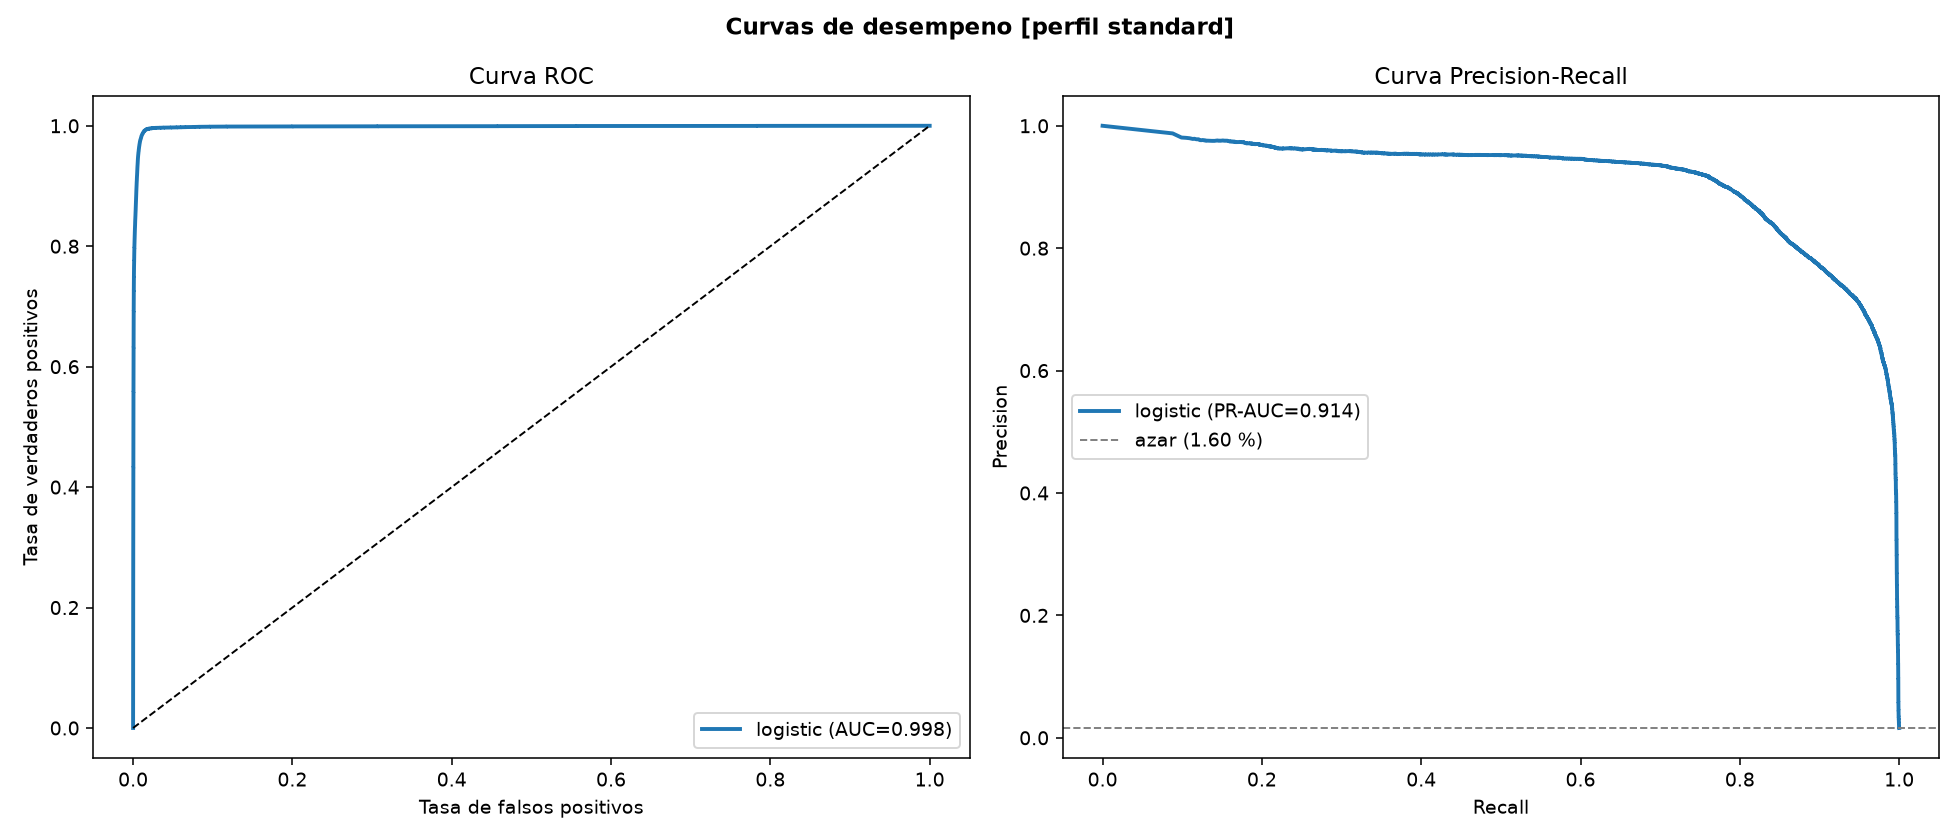

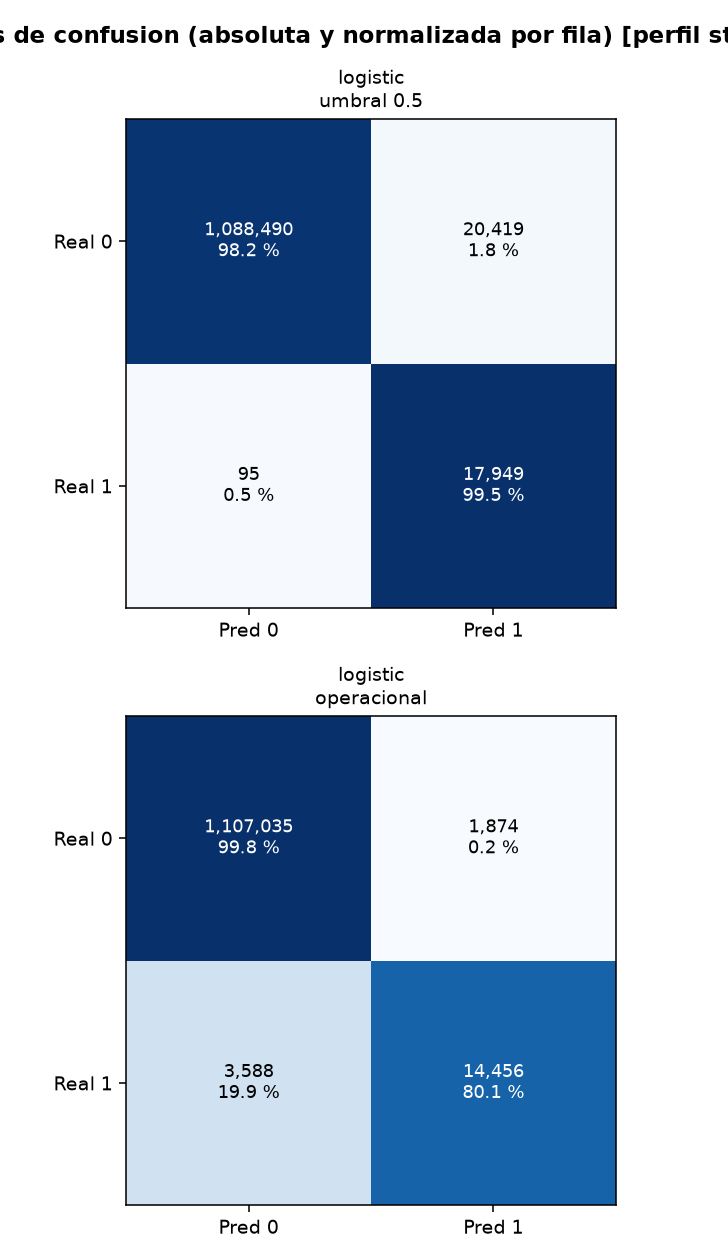

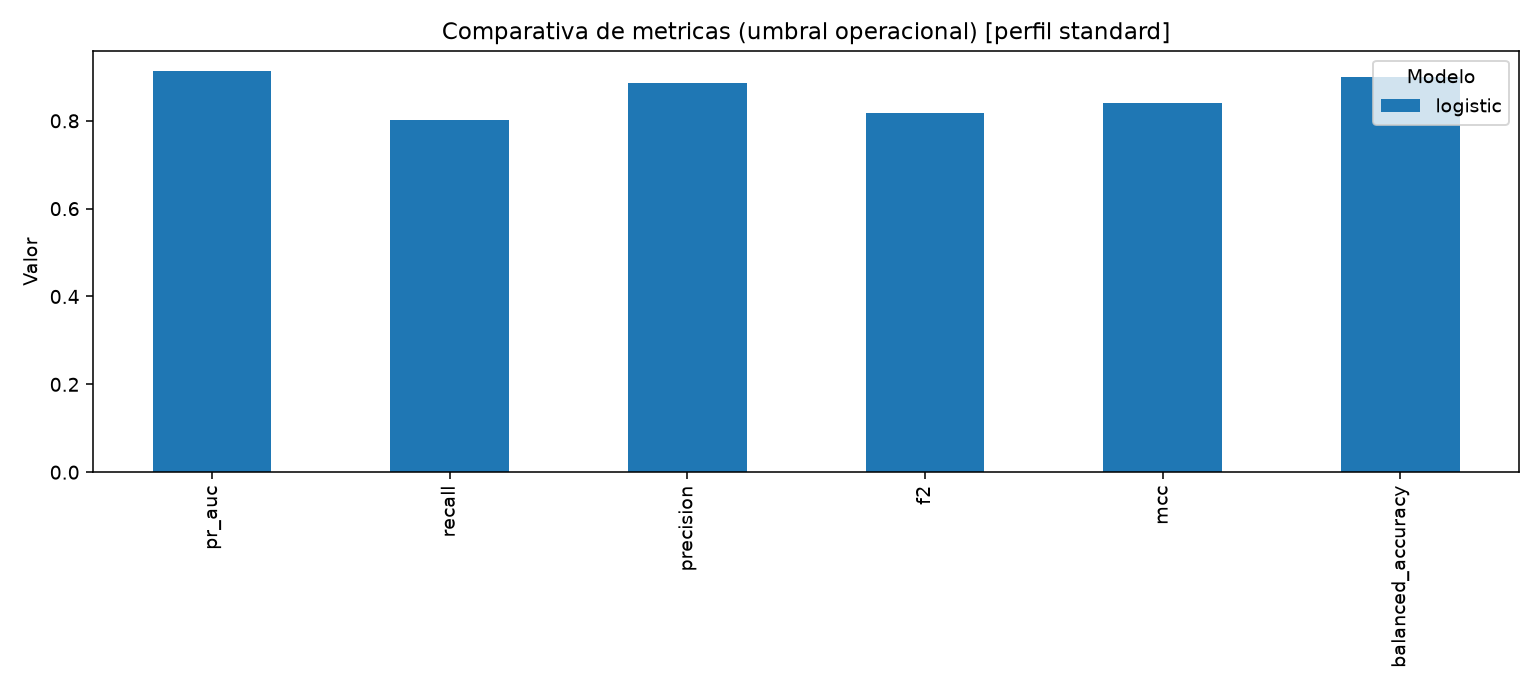

In [22]:
display(Image(filename=str(FIG / "random" / "curvas_roc_pr.png")))
display(Image(filename=str(FIG / "random" / "matrices_confusion.png")))
display(Image(filename=str(FIG / "random" / "comparativa_metricas.png")))

### 5.3 Análisis ambiental de los errores

**Falso positivo (FP):** se marca como zona de alta cianobacteria un área que no lo es.
Cuesta una inspección de campo innecesaria y una alarma infundada.

**Falso negativo (FN):** una zona con floración alta pasa desapercibida. No se emite
aviso, puede haber exposición recreativa o consumo sin advertencia, y se pierde la
ventana de intervención temprana.

**El falso negativo es el error más grave** en vigilancia ambiental: un aviso de más
cuesta una visita; un aviso de menos puede costar salud pública. Por eso:

- La métrica prioritaria es el **Recall** de la clase positiva.
- Se compara con **PR-AUC**, mucho más informativo que ROC-AUC con 1.6 % de positivos.
- Se reporta **F2**, que pondera el Recall por encima de la Precision.

**El umbral operacional se eligió sin usar el test**: se exigió Recall ≥ 0.80 sobre una
validación interna extraída del entrenamiento y, entre los umbrales que lo cumplían, se
tomó el de mayor Precision.

> **Alcance.** Es una herramienta de **cribado**, no una medición confirmatoria. Sin
> validación in situ, con un algoritmo de MAPE 42.3 % calibrado para *M. aeruginosa* sobre
> datos simulados. **No diagnostica toxicidad**: la clorofila mide biomasa, no toxinas.


---

# Ejercicio 6. Validación espacial

Bloques de **1 km × 1 km** derivados de las coordenadas UTM (**EPSG:32615**), con
`StratifiedGroupKFold`: ningún bloque aparece a la vez en entrenamiento y validación.


In [23]:
sp = pd.read_csv(MET / "spatial" / "metricas_por_fold_standard.csv")
spv = sp[sp["valido"] == True]
print(f"Folds: {spv['fold'].nunique()} | Bloques compartidos entre train y val: "
      f"{int(spv['bloques_compartidos'].sum())}")
display(spv[["fold", "bloques_train", "bloques_val", "n", "TP", "FN",
             "prevalencia_real", "lagos_val"]].drop_duplicates("fold").round(5))

display(spv[["fold", "modelo", "pr_auc", "recall", "precision", "f2", "mcc"]].round(4))

Folds: 5 | Bloques compartidos entre train y val: 0


,fold,bloques_train,bloques_val,n,TP,FN,prevalencia_real,lagos_val
0,1,267,41,751226,8932,2924,0.01578,"Amatitlan,Atitlan"
2,2,249,59,751885,8980,3682,0.01684,"Amatitlan,Atitlan"
4,3,234,74,751054,10571,1226,0.01571,"Amatitlan,Atitlan"
6,4,240,68,751109,7501,4351,0.01578,"Amatitlan,Atitlan"
8,5,242,66,751236,9550,2429,0.01595,"Amatitlan,Atitlan"


,fold,modelo,pr_auc,recall,precision,f2,mcc
0,1,random_forest,0.9728,0.7534,0.9846,0.7905,0.8594
1,1,xgboost,0.9750,0.7889,0.9813,0.8211,0.8782
2,2,random_forest,0.9677,0.7092,0.9761,0.7502,0.8297
3,2,xgboost,0.9724,0.7247,0.9850,0.7651,0.8427
4,3,random_forest,0.9939,0.8961,0.9942,0.9141,0.9430
5,3,xgboost,0.9934,0.8971,0.9927,0.9147,0.9428
6,4,random_forest,0.9615,0.6329,0.9827,0.6814,0.7862
7,4,xgboost,0.9532,0.6647,0.9563,0.7079,0.7948
8,5,random_forest,0.9829,0.7972,0.9889,0.8294,0.8864
9,5,xgboost,0.9843,0.8199,0.9857,0.8484,0.8975


In [24]:
agg_s = pd.read_csv(MET / "spatial" / "agregado_standard.csv")
print("Agregado espacial (media ± desviación, rango):")
display(agg_s[["modelo", "pr_auc_mean", "pr_auc_std", "pr_auc_min", "pr_auc_max",
               "recall_mean", "precision_mean"]].round(4))

mejor_esp = json.loads((MET / "spatial" / "mejor_modelo_standard.json").read_text(encoding="utf-8"))
print(f"\nModelo seleccionado: {mejor_esp['mejor_modelo']} "
      f"(PR-AUC {mejor_esp['pr_auc_medio']:.4f})")
print(f"Criterio: {mejor_esp['criterio']}")

dif = abs(agg_s.set_index("modelo").loc["random_forest", "pr_auc_mean"]
          - agg_s.set_index("modelo").loc["xgboost", "pr_auc_mean"])
print(f"\nDiferencia RF - XGBoost: {dif:.4f}")
print("Es un EMPATE PRÁCTICO, no una superioridad sustantiva: la diferencia es")
print("mucho menor que la desviación entre folds. Random Forest se selecciona por")
print("la regla determinista de mayor PR-AUC medio, no porque sea mejor modelo.")

Agregado espacial (media ± desviación, rango):


,modelo,pr_auc_mean,pr_auc_std,pr_auc_min,pr_auc_max,recall_mean,precision_mean
0,logistic,0.9026,0.0563,0.8285,0.9636,0.7873,0.8778
1,random_forest,0.9758,0.0128,0.9615,0.9939,0.7578,0.9853
2,xgboost,0.9757,0.0150,0.9532,0.9934,0.7790,0.9802



Modelo seleccionado: random_forest (PR-AUC 0.9758)


Criterio: mayor PR-AUC medio en validacion espacial

Diferencia RF - XGBoost: 0.0001
Es un EMPATE PRÁCTICO, no una superioridad sustantiva: la diferencia es
mucho menor que la desviación entre folds. Random Forest se selecciona por
la regla determinista de mayor PR-AUC medio, no porque sea mejor modelo.


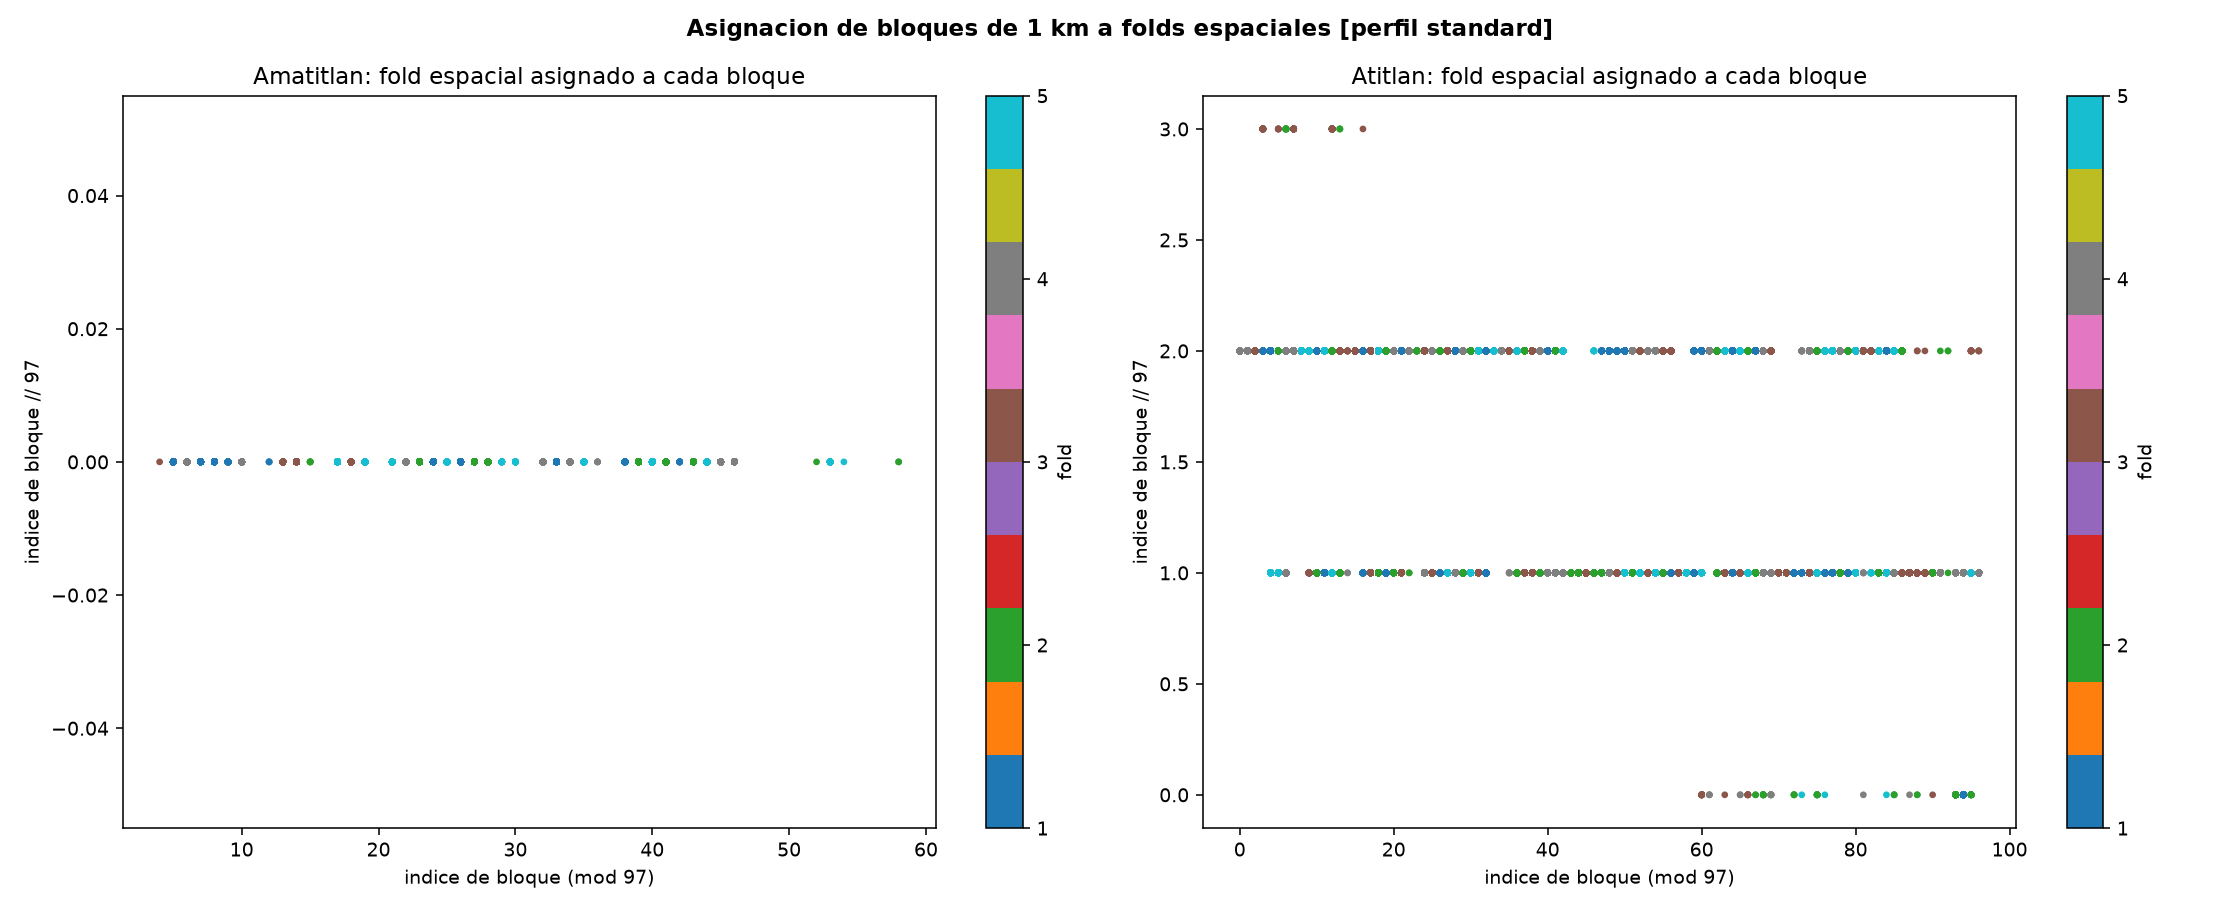

Comparación: división aleatoria vs validación espacial (PR-AUC)


,aleatorio,espacial,caida_absoluta,caida_relativa_%
modelo,,,,
logistic,0.9135,0.9026,-0.0109,-1.1972
random_forest,0.9814,0.9758,-0.0056,-0.5742
xgboost,0.9826,0.9757,-0.0069,-0.6991


In [25]:
display(Image(filename=str(FIG / "spatial" / "folds_espaciales_standard.png")))

print("Comparación: división aleatoria vs validación espacial (PR-AUC)")
rr = r[r["etiqueta"] == "umbral_0.5"].set_index("modelo")["pr_auc"]
ss = agg_s.set_index("modelo")["pr_auc_mean"]
cmp = pd.DataFrame({"aleatorio": rr, "espacial": ss})
cmp["caida_absoluta"] = cmp["espacial"] - cmp["aleatorio"]
cmp["caida_relativa_%"] = 100 * cmp["caida_absoluta"] / cmp["aleatorio"]
display(cmp.round(4))

### Interpretación

La caída del aleatorio al espacial es **pequeña en magnitud** pero **no significa ausencia
de dependencia espacial**. Hay tres señales que obligan a matizarlo:

1. **La variabilidad entre folds crece mucho.** Regresión Logística pasa de un valor único
   a 0.9026 ± 0.0563, con rango [0.8285, 0.9636]: casi 14 puntos entre el mejor y el peor
   fold. Esa dispersión es la huella de la heterogeneidad espacial.
2. **Los positivos están concentrados**: 37.7 % en 5 bloques y 87.6 % en 5 fechas. Un fold
   que capture o pierda uno de esos bloques cambia sustancialmente su dificultad.
3. **La validación espacial estima mejor** la capacidad de predecir en una **zona nueva**,
   porque la división aleatoria coloca píxeles vecinos casi idénticos a ambos lados.

La caída modesta sugiere que la señal espectral es genuinamente transferible **dentro del
mismo lago**, pero el Ejercicio 7 muestra que eso no se extiende a otro lago.


---

# Validación temporal (exigida por la rúbrica)

Ventana expansiva (*rolling origin*): las fechas de ambos lagos se ordenan en una línea
temporal común y cada corte entrena **solo con el pasado**. Una aserción impide que una
fecha esté a la vez en entrenamiento y prueba.


In [26]:
tp = pd.read_csv(MET / "temporal" / "metricas_por_fold_standard.csv")
tpv = tp[tp["valido"] == True]
print(f"Folds temporales: {tpv['fold'].nunique()}")
display(tpv[["fold", "train_hasta", "test_fecha", "modelo", "prevalencia_real",
             "pr_auc", "recall", "precision", "f2",
             "prevalencia_inestable"]].round(4).head(24))

Folds temporales: 16


,fold,train_hasta,test_fecha,modelo,prevalencia_real,pr_auc,recall,precision,f2,prevalencia_inestable
0,1,2025-01-18 .. 2025-04-15,2025-04-28,random_forest,0.1358,0.9185,0.7586,0.8744,0.7792,False
1,1,2025-01-18 .. 2025-04-15,2025-04-28,xgboost,0.1358,0.9107,0.7978,0.8037,0.7990,False
2,2,2025-01-18 .. 2025-04-28,2025-05-13,random_forest,0.0001,0.1307,0.2174,0.1471,0.1984,True
3,2,2025-01-18 .. 2025-04-28,2025-05-13,xgboost,0.0001,0.1842,0.0000,0.0000,0.0000,True
4,3,2025-01-18 .. 2025-05-13,2025-07-17,random_forest,0.0012,0.6617,0.4298,0.7426,0.4693,False
5,3,2025-01-18 .. 2025-05-13,2025-07-17,xgboost,0.0012,0.5945,0.2779,0.7760,0.3189,False
6,4,2025-01-18 .. 2025-07-17,2025-11-21,random_forest,0.0011,0.8437,0.6577,0.8760,0.6922,False
7,4,2025-01-18 .. 2025-07-17,2025-11-21,xgboost,0.0011,0.7960,0.5165,0.9149,0.5658,False
8,5,2025-01-18 .. 2025-11-21,2025-11-24,random_forest,0.0282,0.9137,0.6171,0.9393,0.6626,False
9,5,2025-01-18 .. 2025-11-21,2025-11-24,xgboost,0.0282,0.9023,0.6599,0.9263,0.7001,False


In [27]:
agg_t = pd.read_csv(MET / "temporal" / "agregado_standard.csv")
agg_te = pd.read_csv(MET / "temporal" / "agregado_estables_standard.csv")
print("=== Agregado con TODOS los folds ===")
display(agg_t[["modelo", "pr_auc_mean", "pr_auc_std", "pr_auc_min",
               "pr_auc_max", "recall_mean"]].round(4))
print("=== Agregado solo con folds de prevalencia NO extrema ===")
display(agg_te.round(4))

ext = sorted(tpv[tpv["prevalencia_inestable"] == True]["fold"].unique())
print(f"Folds de prevalencia extrema: {ext}")
print("Se publican los dos agregados por separado porque mezclarlos ocultaría")
print("que dos folds dominan la media: en ellos la Precision y el PR-AUC son")
print("muy inestables por tener casi ningún positivo o casi todos.")

=== Agregado con TODOS los folds ===


,modelo,pr_auc_mean,pr_auc_std,pr_auc_min,pr_auc_max,recall_mean
0,logistic,0.6429,0.2839,0.1323,0.9800,0.7795
1,random_forest,0.7416,0.2510,0.1307,0.9879,0.4991
2,xgboost,0.7042,0.2571,0.1842,0.9884,0.4312


=== Agregado solo con folds de prevalencia NO extrema ===


,modelo,pr_auc_mean,pr_auc_std,recall_mean,recall_std,precision_mean,precision_std
0,logistic,0.6374,0.2812,0.7903,0.1018,0.4836,0.3094
1,random_forest,0.7676,0.1964,0.5064,0.2018,0.8436,0.1903
2,xgboost,0.7210,0.2212,0.4352,0.2045,0.8498,0.1959


Folds de prevalencia extrema: [np.int64(2), np.int64(15)]
Se publican los dos agregados por separado porque mezclarlos ocultaría
que dos folds dominan la media: en ellos la Precision y el PR-AUC son
muy inestables por tener casi ningún positivo o casi todos.


In [28]:
print("Mejor y peor fecha por modelo:")
mejor = tpv.loc[tpv.groupby("modelo")["pr_auc"].idxmax()][
    ["modelo", "fold", "test_fecha", "prevalencia_real", "pr_auc"]]
peor = tpv.loc[tpv.groupby("modelo")["pr_auc"].idxmin()][
    ["modelo", "fold", "test_fecha", "prevalencia_real", "pr_auc"]]
display(pd.concat([mejor.assign(caso="mejor"), peor.assign(caso="peor")]).round(5))

print("\nComparación de las tres estrategias (PR-AUC):")
tt = agg_t.set_index("modelo")["pr_auc_mean"]
display(pd.DataFrame({"aleatorio": rr, "espacial": ss, "temporal": tt}).round(4))

Mejor y peor fecha por modelo:


,modelo,fold,test_fecha,prevalencia_real,pr_auc,caso
46,logistic,15,2026-06-19,0.62919,0.98003,mejor
28,random_forest,15,2026-06-19,0.62919,0.98790,mejor
29,xgboost,15,2026-06-19,0.62919,0.98839,mejor
37,logistic,6,2025-12-29,0.00083,0.13229,peor
2,random_forest,2,2025-05-13,0.00008,0.13068,peor
3,xgboost,2,2025-05-13,0.00008,0.18416,peor



Comparación de las tres estrategias (PR-AUC):


,aleatorio,espacial,temporal
modelo,,,
logistic,0.9135,0.9026,0.6429
random_forest,0.9814,0.9758,0.7416
xgboost,0.9826,0.9757,0.7042


### Interpretación temporal

La validación temporal es **con diferencia la más exigente**: el PR-AUC medio cae de
~0.98 (aleatorio) y ~0.976 (espacial) a **0.70–0.74**, con desviaciones de ~0.25.

**Casos concretos, favorables y desfavorables:**

- **Mejor fecha:** 2026-06-19 (fold 15), con PR-AUC 0.98–0.99 en los tres modelos. Es
  también un fold de **prevalencia extrema** (62.9 % de positivos): con tantos positivos,
  acertar es mucho más fácil, así que **no debe presentarse como éxito representativo**.
- **Peor fecha:** 2025-05-13 (fold 2) con PR-AUC 0.13–0.18, y 2025-12-29 (fold 6) para
  Regresión Logística con 0.1323. Son fechas con muy pocos positivos donde el modelo
  entrenado con el pasado falla casi por completo.

**Evidencia de cambio distribucional.** Que un modelo funcione casi perfecto en una fecha
y colapse en otra indica que la relación entre reflectancia y clorofila **no es estable en
el tiempo**: cambian la iluminación, la atmósfera, el estado del agua y la composición de
la comunidad algal.

**Riesgo de generalizar a fechas futuras: alto.** No se debe seleccionar solo los folds
favorables para concluir; el promedio honesto incluye los malos, y la desviación de ~0.25
es tan informativa como la media.


---

# Ejercicio 7. Generalización entre lagos

Se usa el modelo seleccionado por **validación espacial** (Random Forest), no el mejor del
split aleatorio. Los pesos de clase y el umbral operacional se calculan **solo con el lago
de entrenamiento**.


In [29]:
cl = pd.read_csv(MET / "cross_lake" / "metricas_standard.csv")
display(cl[["experimento", "train", "test", "etiqueta", "prevalencia_train",
            "prevalencia_test", "pr_auc", "roc_auc", "recall", "precision",
            "f1", "f2", "mcc", "TP", "FN", "FP", "TN"]].round(4))

pa = cl["prevalencia_train"].max() / cl["prevalencia_train"].min()
print(f"Asimetría de prevalencia entre lagos: {pa:.0f}x")
print(f"  Amatitlán: {100*cl['prevalencia_test'].max():.4f} % de positivos")
print(f"  Atitlán  : {100*cl['prevalencia_test'].min():.4f} % de positivos")

,experimento,train,test,etiqueta,prevalencia_train,prevalencia_test,pr_auc,roc_auc,recall,precision,f1,f2,mcc,TP,FN,FP,TN
0,A,Atitlan,Amatitlan,umbral_0.5,0.0006,0.1451,0.7851,0.9518,0.0159,0.9286,0.0313,0.0198,0.1111,924,57072,71,341579
1,A,Atitlan,Amatitlan,umbral_operacional,0.0006,0.1451,0.7851,0.9518,0.0401,0.9230,0.0768,0.0496,0.1758,2324,55672,194,341456
2,B,Amatitlan,Atitlan,umbral_0.5,0.1451,0.0006,0.5081,0.9939,0.7744,0.4690,0.5842,0.6852,0.6024,1665,485,1885,3352829
3,B,Amatitlan,Atitlan,umbral_operacional,0.1451,0.0006,0.5081,0.9939,0.1312,0.5949,0.2149,0.1554,0.2792,282,1868,192,3354522


Asimetría de prevalencia entre lagos: 227x
  Amatitlán: 14.5118 % de positivos
  Atitlán  : 0.0640 % de positivos


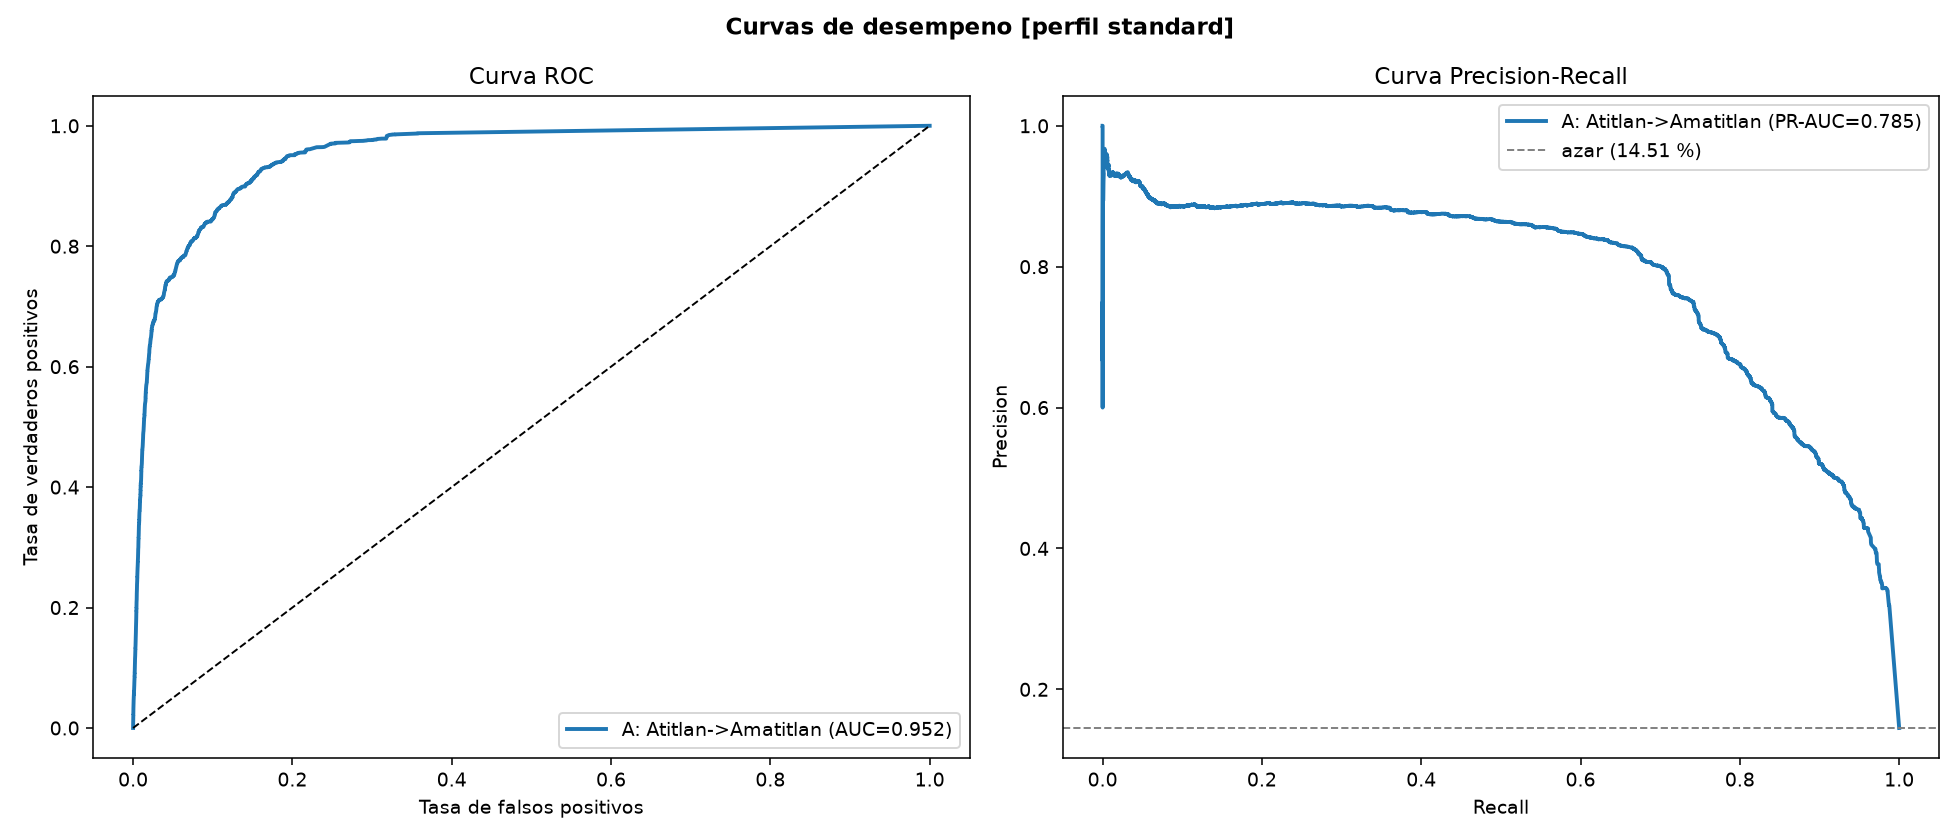

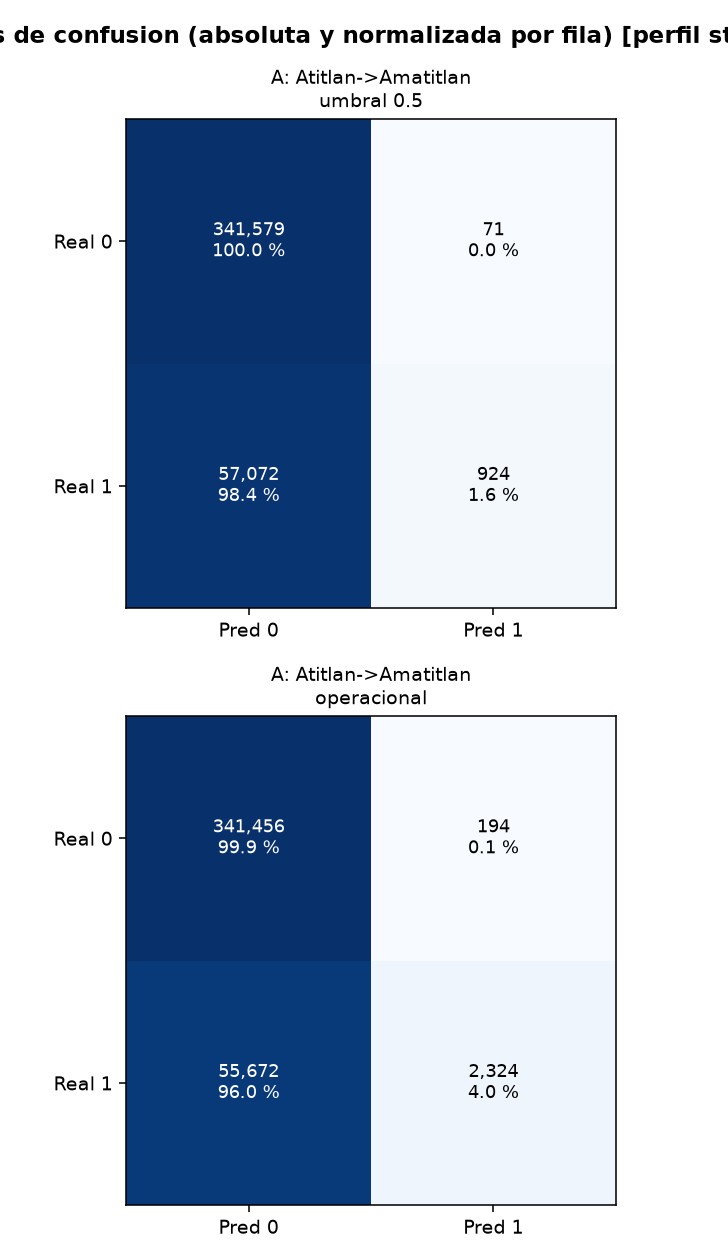

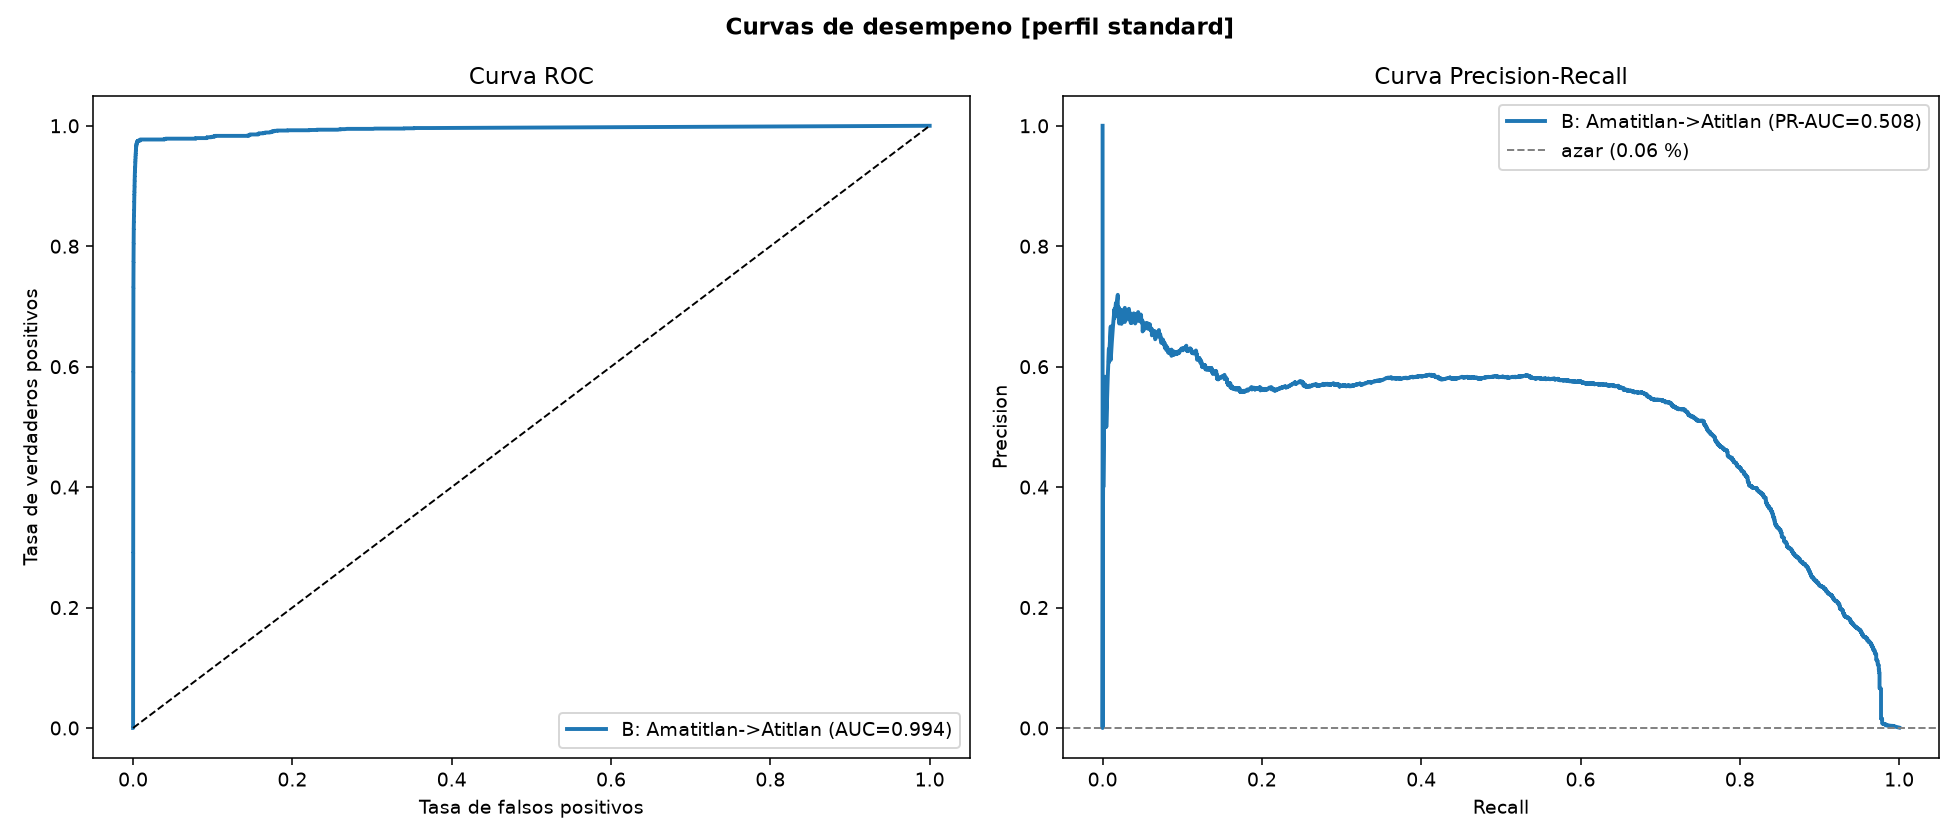

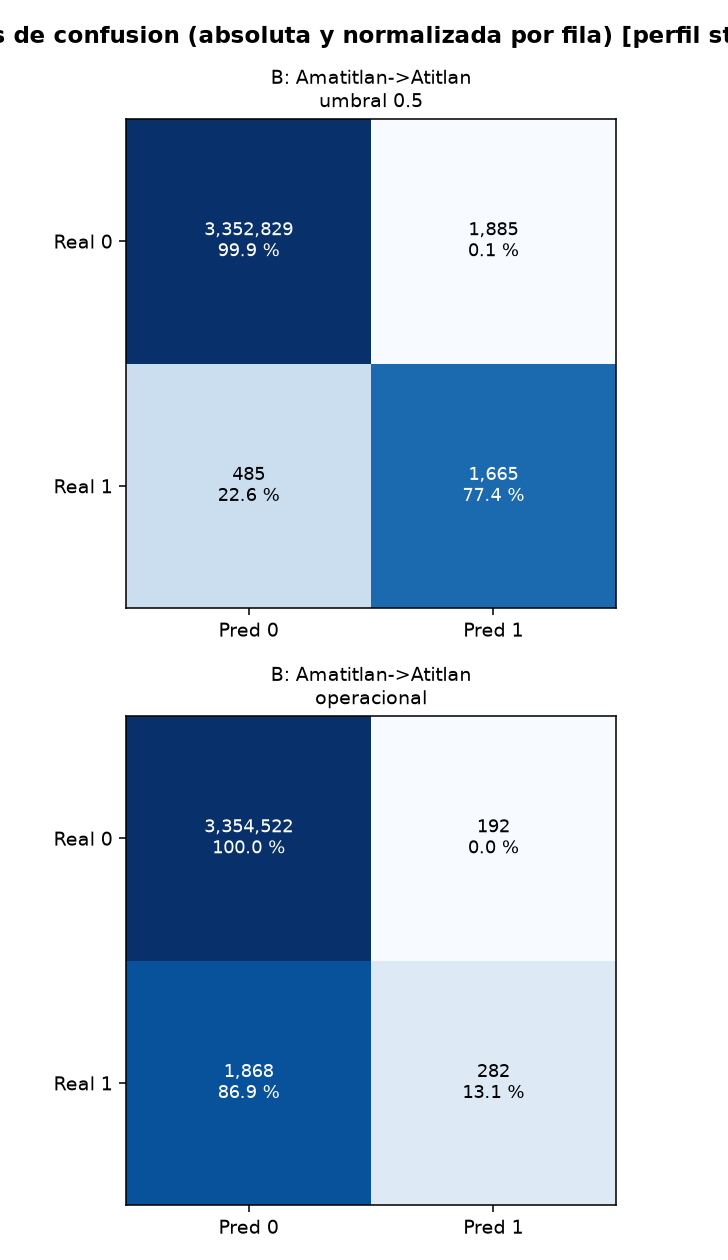

In [30]:
display(Image(filename=str(FIG / "cross_lake" / "curvas_roc_pr_A.png")))
display(Image(filename=str(FIG / "cross_lake" / "matrices_confusion_A.png")))
display(Image(filename=str(FIG / "cross_lake" / "curvas_roc_pr_B.png")))
display(Image(filename=str(FIG / "cross_lake" / "matrices_confusion_B.png")))

### Conclusión: el modelo NO generaliza adecuadamente entre lagos

**Experimento A — Atitlán → Amatitlán.** PR-AUC 0.7851, que a primera vista parece
aceptable. Pero bajo el umbral operacional el **Recall es 0.040**: detecta 2,324 zonas
positivas y **se le escapan 55,672**. Un PR-AUC alto **no equivale a generalización
satisfactoria** cuando el recall operativo es del 4 %.

**Experimento B — Amatitlán → Atitlán.** PR-AUC 0.5081, apenas por encima del azar en
términos de ordenamiento útil. A umbral 0.5 el Recall es 0.774, pero al aplicar el umbral
operacional cae a **0.131**: 282 detectados frente a 1,868 perdidos.

### Cuatro cosas distintas que conviene no confundir

| Concepto | Qué mide | Qué pasó aquí |
|---|---|---|
| **Discriminación (PR-AUC)** | Capacidad de ordenar positivos por encima de negativos | Moderada en A (0.785), pobre en B (0.508) |
| **Clasificación bajo umbral** | Decisiones reales con un corte fijo | Falla en ambos: Recall 4 % y 13 % |
| **Cambio de probabilidad base** | La prevalencia pasa de 0.064 % a 14.51 % (≈227×) | Invalida el umbral aprendido |
| **Transferencia espectral** | Si la relación reflectancia→clorofila es la misma | Parcial: hay señal, pero no calibrada |

**El umbral operacional aprendido en una distribución no se transfiere a otra.** Se
calibró para que en el lago de origen el Recall fuera ≥ 0.80; al aplicarlo sobre un lago
con una prevalencia dos órdenes de magnitud distinta, la probabilidad predicha se
desplaza y ese mismo corte deja fuera la mayoría de los positivos.

**Utilidad ambiental.** Un modelo entrenado en un lago **no sirve como sistema de alerta
en el otro** sin recalibrar al menos el umbral con datos locales. Los resultados
desfavorables se reportan tal cual: no se modificó el umbral de 8 µg/L ni ningún
parámetro para mejorar artificialmente la transferencia.


---

# Ejercicio 8. Interpretabilidad del Random Forest

Se cargan los artefactos ya generados por `explicabilidad_mapas_parte2.py --explain --profile
standard`. **Este cuaderno no reentrena el modelo ni recalcula SHAP.**


In [31]:
INT = P2 / "interpretability"
MAPS = P2 / "maps"
CONC = P2 / "conclusions"

meta = json.loads((INT / "interpretabilidad_meta_standard.json").read_text(encoding="utf-8"))
print("Modelo interpretado:", meta["modelo"], "| hiperparámetros:", meta["hiperparametros"])
print("Ajuste sobre:", f"{meta['n_ajuste']:,}", "filas | evaluación NO vista:",
      f"{meta['n_evaluacion_no_vista']:,}", "filas (bloques disjuntos)")
print("Muestra SHAP:", f"{meta['n_shap']:,}", "filas |",
      f"{meta['segundos']['shap']:.1f} s")
print(f"Prevalencia en la muestra SHAP: {100*meta['prevalencia_muestra_shap']:.2f} % "
      f"(poblacional: {100*meta['prevalencia_poblacional']:.4f} %)")
for a in meta["advertencias"]:
    print(" -", a)

Modelo interpretado: random_forest | hiperparámetros: {'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': None}
Ajuste sobre: 3,005,284 filas | evaluación NO vista: 751,226 filas (bloques disjuntos)
Muestra SHAP: 15,704 filas | 1569.8 s
Prevalencia en la muestra SHAP: 36.40 % (poblacional: 1.6011 %)
 - SHAP no implica causalidad: describe la contribucion a la prediccion del modelo, no un mecanismo fisico.
 - Las bandas espectrales estan fuertemente correlacionadas entre si, asi que la importancia se reparte entre variables redundantes; un valor bajo no significa que la banda sea prescindible.
 - La respuesta es un proxy espectral de clorofila-a, no una medicion in situ.
 - La muestra SHAP sobrerrepresenta la clase positiva: NO reproduce la prevalencia poblacional, por lo que las magnitudes son importancia relativa, no frecuencia esperada en el lago.


In [32]:
nativa = pd.read_csv(INT / "importancia_nativa_standard.csv")
perm = pd.read_csv(INT / "permutation_importance_standard.csv")
shap_df = pd.read_csv(INT / "shap_abs_media_standard.csv")

print("Importancia nativa (impureza):")
display(nativa)
print("\nPermutation importance (sobre observaciones NO usadas para ajustar el modelo):")
display(perm)
print("\nSHAP: media del valor absoluto:")
display(shap_df)

Importancia nativa (impureza):


,variable,importancia_impureza
0,B07,0.329541
1,B03,0.220984
2,B08,0.148803
3,B8A,0.144510
4,NDWI,0.068721
5,B02,0.041167
6,B11,0.025883
7,B12,0.020393



Permutation importance (sobre observaciones NO usadas para ajustar el modelo):


,variable,caida_media_pr_auc,desviacion
0,B07,0.875872,0.003925
1,B03,0.069160,0.001317
2,NDWI,0.064467,0.001720
3,B08,0.053859,0.002361
4,B8A,0.049402,0.001710
5,B02,0.031759,0.001533
6,B12,0.022720,0.001004
7,B11,0.016780,0.000486



SHAP: media del valor absoluto:


,variable,shap_abs_media
0,B07,0.210829
1,B03,0.092964
2,B8A,0.065942
3,B08,0.061721
4,B02,0.037964
5,B12,0.031201
6,NDWI,0.030416
7,B11,0.026939


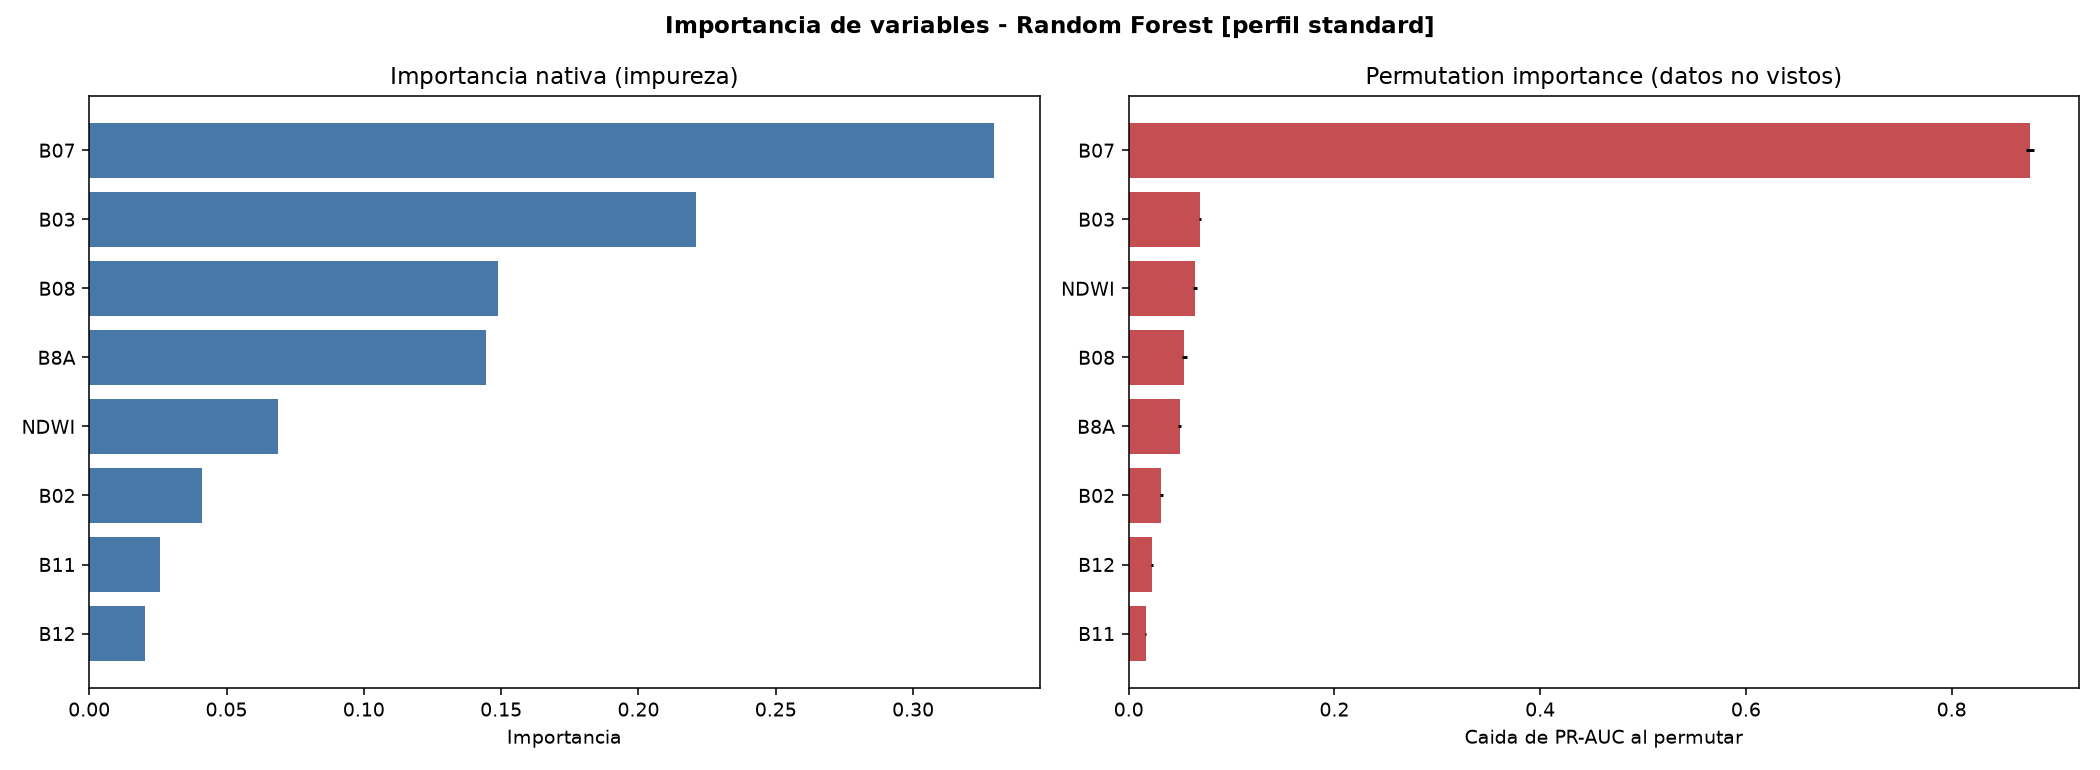

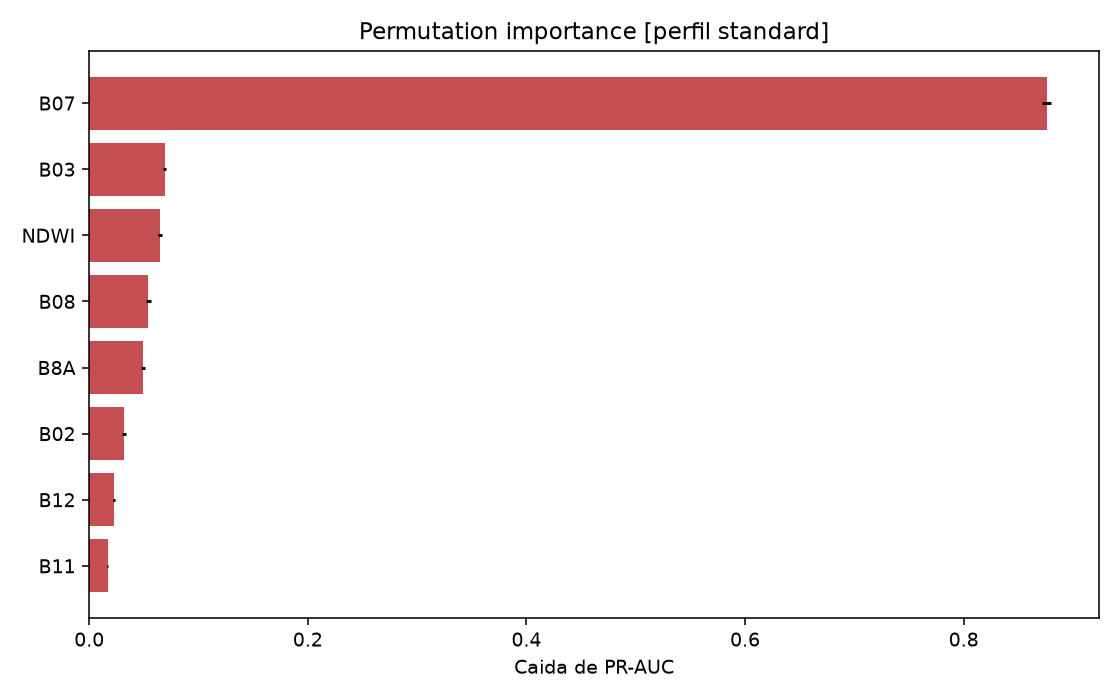

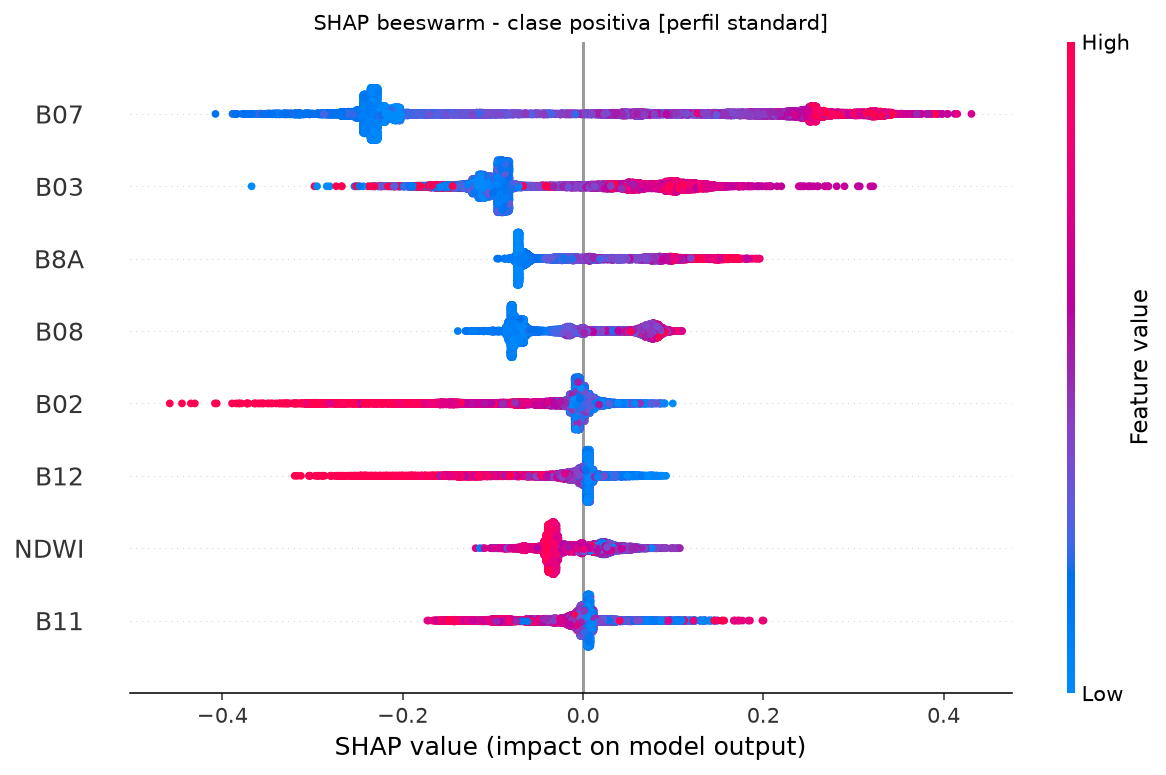

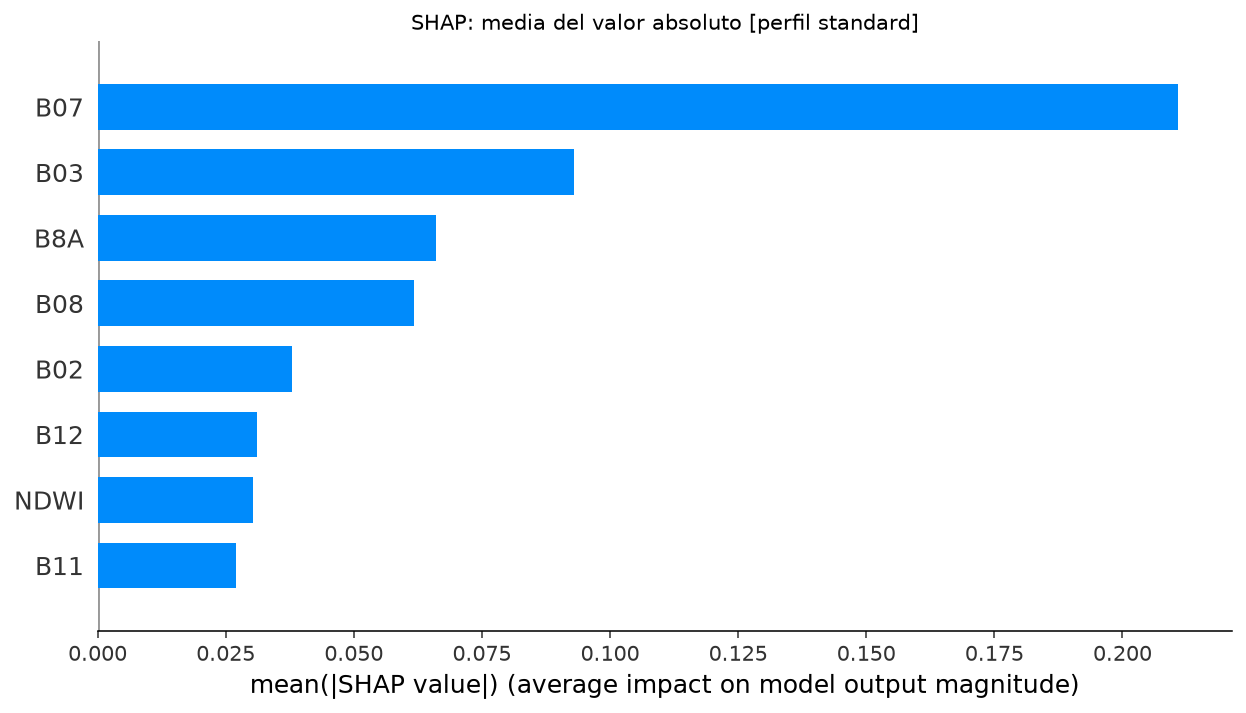

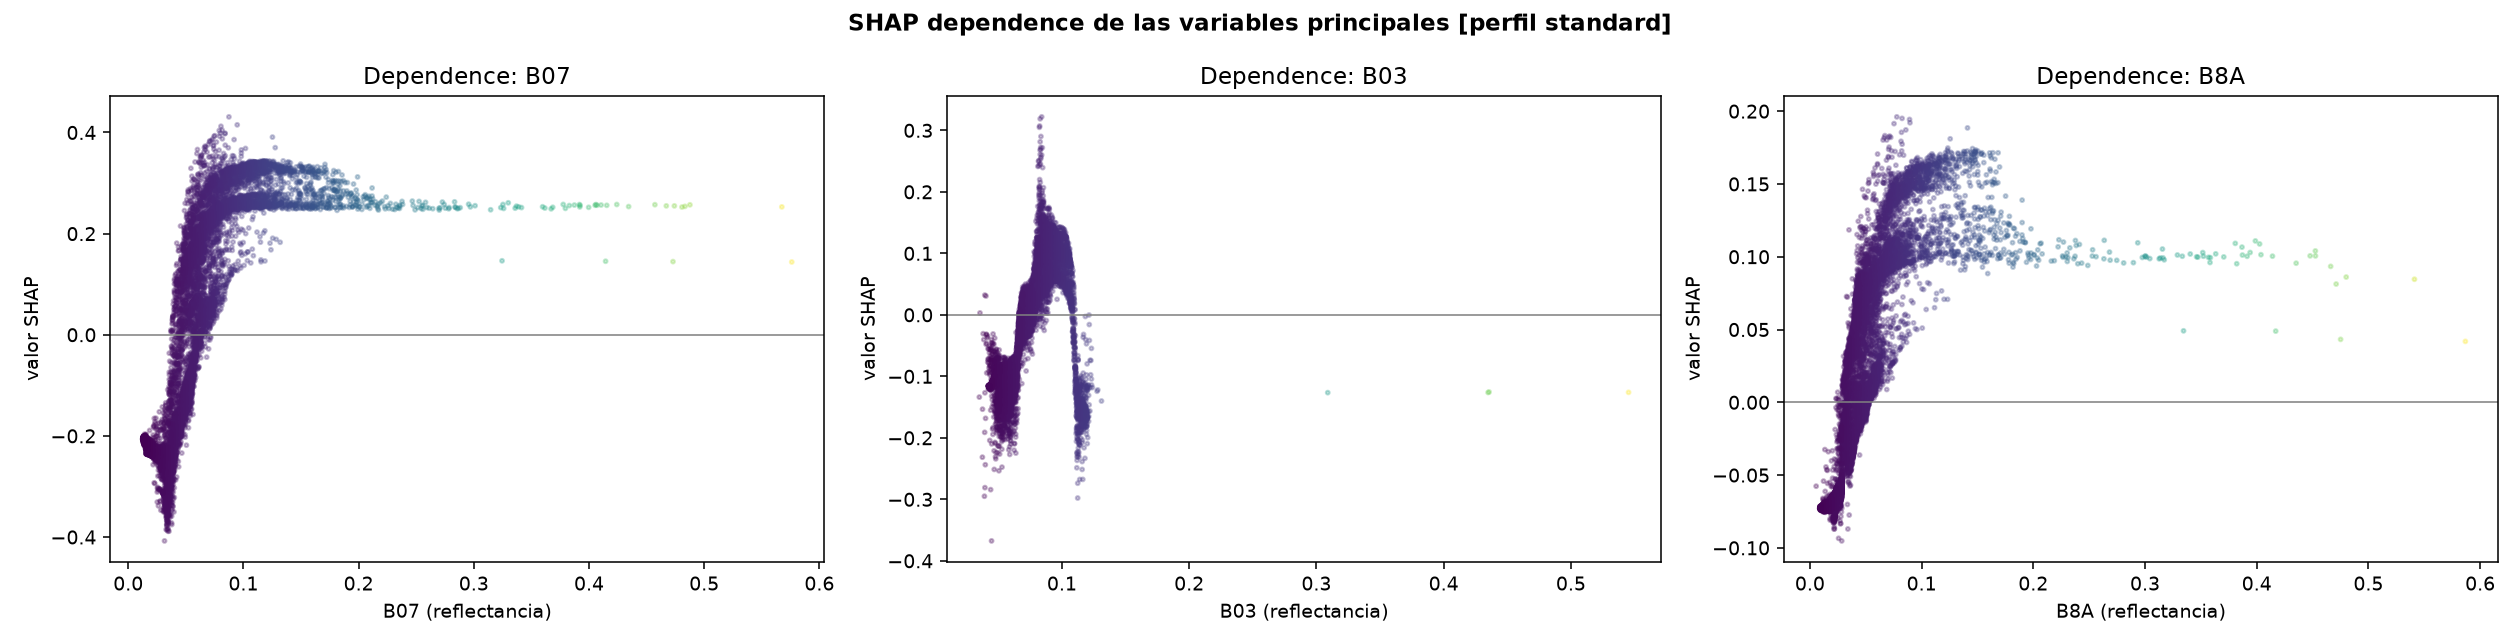

In [33]:
display(Image(filename=str(INT / "importancia_nativa_standard.png")))
display(Image(filename=str(INT / "permutation_importance_standard.png")))
display(Image(filename=str(INT / "shap_beeswarm_standard.png")))
display(Image(filename=str(INT / "shap_bar_standard.png")))
display(Image(filename=str(INT / "shap_dependence_standard.png")))

### Interpretación

Las tres técnicas coinciden en que **B07** (borde rojo, 783 nm) domina la predicción, seguida de
**B03** (verde). Esto es coherente con el rol del borde rojo en la detección de biomasa algal.

**SHAP no implica causalidad.** Describe la contribución de cada variable a la predicción del
modelo, no un mecanismo físico verificado. Las bandas espectrales están correlacionadas entre sí,
así que la importancia se reparte entre variables redundantes. La muestra SHAP sobrerrepresenta
la clase positiva (36–39 % frente al 1.6 % poblacional): las magnitudes son importancia
**relativa**, no frecuencia esperada en el lago. La respuesta sigue siendo un proxy espectral de
clorofila-a, no una medición in situ.


---

# Ejercicio 9. Mapas predictivos y errores espaciales

Se cargan los 22 GeoTIFF y las figuras ya generadas. **Este cuaderno no reconstruye los mapas.**


In [34]:
resumen_prob = pd.read_csv(MAPS / "probability" / "resumen_probabilidad_standard.csv")
display(resumen_prob[["lago", "fecha", "n_pixeles", "prob_media", "pct_sobre_umbral",
                      "area_positiva_ha", "positivos_reales"]].round(4))
print(f"\nTotal de GeoTIFF generados: {len(resumen_prob)}")

,lago,fecha,n_pixeles,prob_media,pct_sobre_umbral,area_positiva_ha,positivos_reales
0,Amatitlan,2025-01-28,36550,0.0034,0.0027,0.04,44
1,Amatitlan,2025-04-15,36184,0.0513,1.4647,21.20,739
2,Amatitlan,2025-04-28,36184,0.1820,9.9630,144.20,4912
3,Amatitlan,2025-11-24,36434,0.0389,1.9679,28.68,1029
4,Amatitlan,2026-01-08,36668,0.1116,7.5434,110.64,3484
5,Amatitlan,2026-02-02,36130,0.0020,0.0000,0.00,6
6,Amatitlan,2026-02-07,36561,0.0025,0.0082,0.12,35
7,Amatitlan,2026-03-29,36594,0.1132,7.0421,103.08,3906
8,Amatitlan,2026-04-13,36786,0.2092,9.4819,139.52,5599
9,Amatitlan,2026-04-28,34911,0.4651,41.0157,572.76,15186



Total de GeoTIFF generados: 22


### Mapas descriptivos (modelo ajustado con TODO el dataset)

> **Por qué esto NO es una validación.** El Random Forest de esta sección se ajustó con el
> 100 % de las 3,756,510 observaciones para producir una capa de probabilidad de despliegue.
> El modelo ya vio esos píxeles durante el entrenamiento, así que su desempeño aparente aquí
> está inflado. Sirve para visualizar dónde el modelo *cree* que hay riesgo, no para medir
> qué tan bien acierta. La medición honesta está en la siguiente sección (out-of-fold).


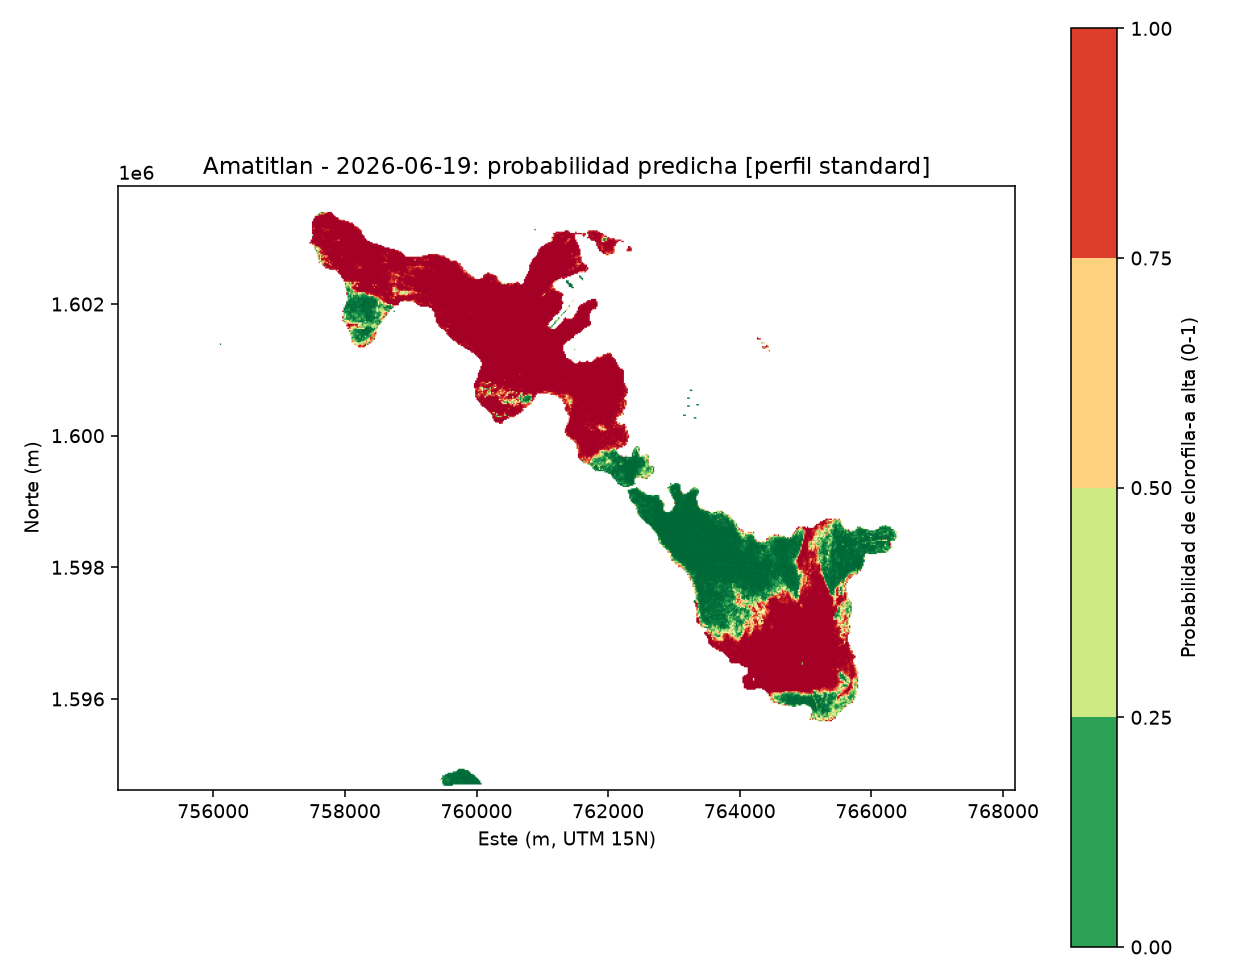

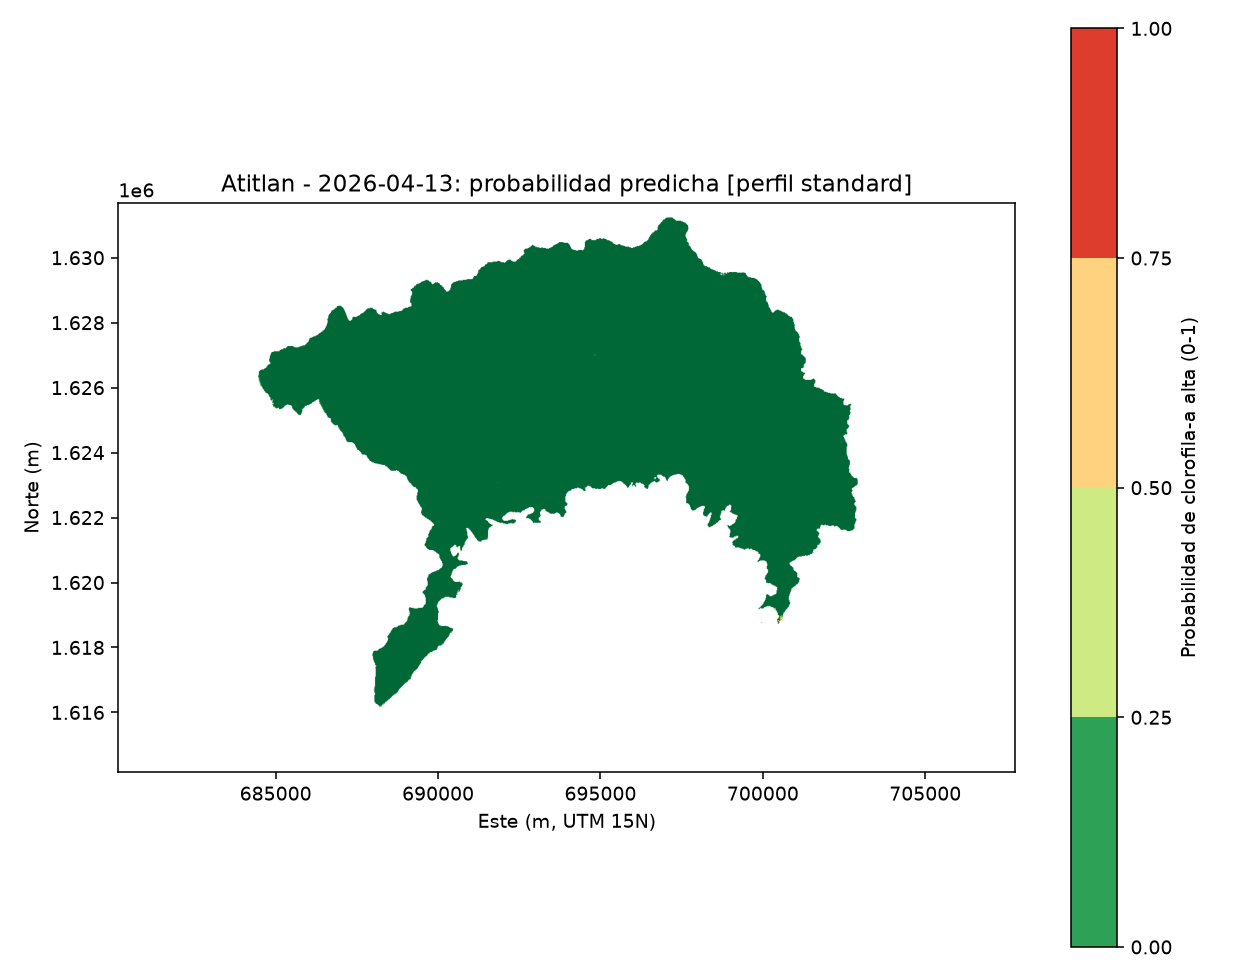

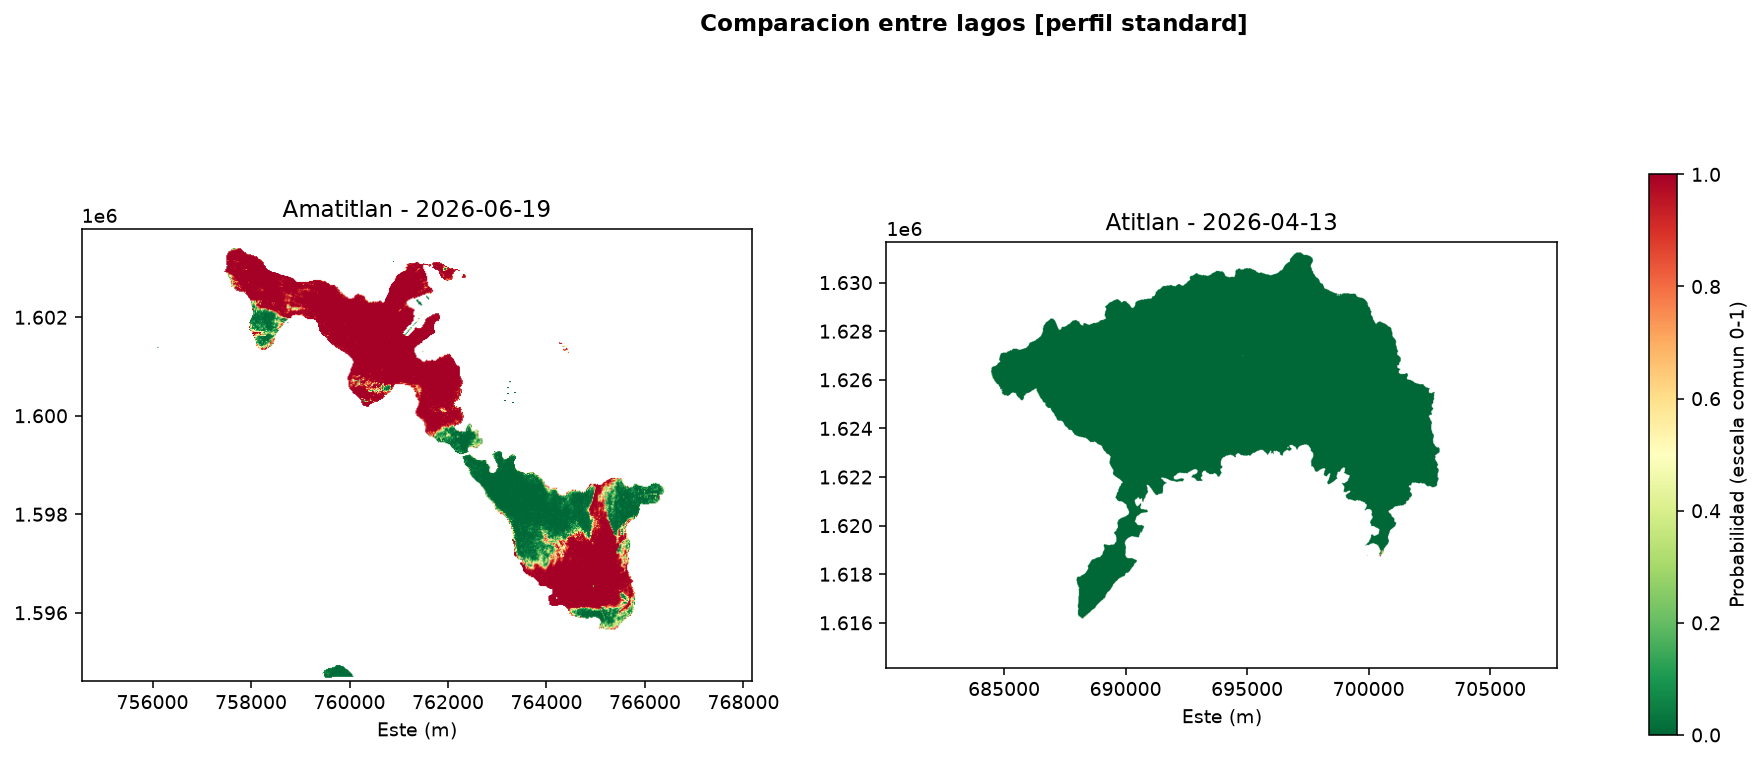

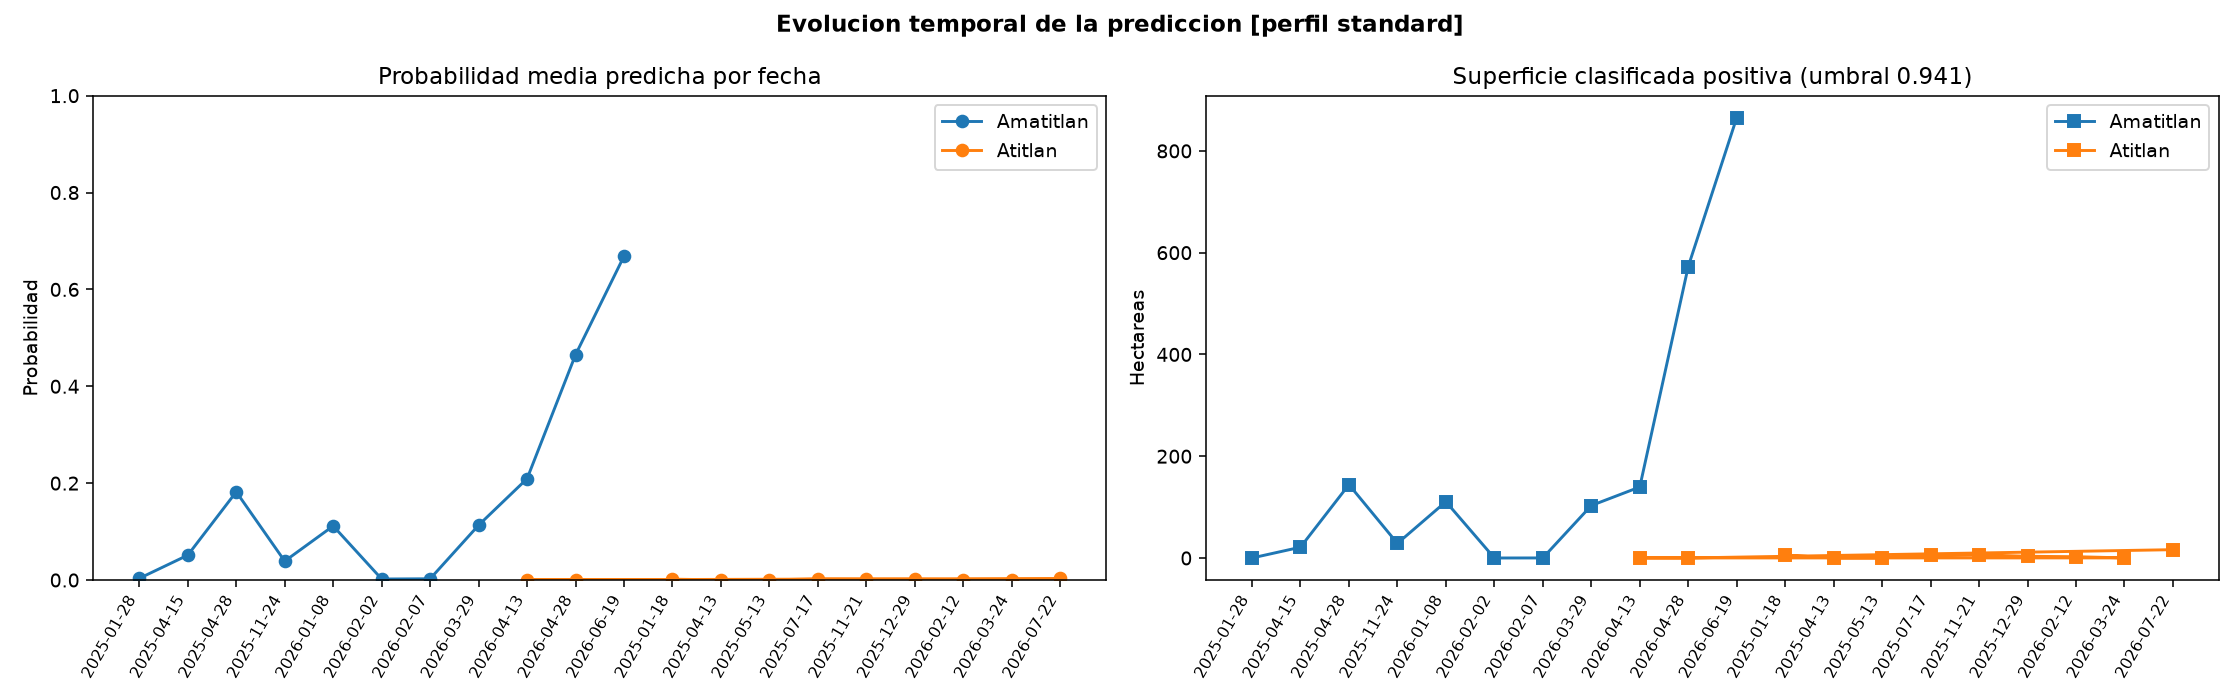

In [35]:
display(Image(filename=str(MAPS / "figures" / "probabilidad_Amatitlan_2026-06-19_standard.png")))
display(Image(filename=str(MAPS / "figures" / "probabilidad_Atitlan_2026-04-13_standard.png")))
display(Image(filename=str(MAPS / "figures" / "comparacion_lagos_standard.png")))
display(Image(filename=str(MAPS / "figures" / "evolucion_temporal_prediccion_standard.png")))

### Errores espaciales out-of-fold (evaluación no sesgada)

Cada una de las 3,756,510 observaciones se predijo **exactamente una vez**, usando los mismos
cinco folds espaciales del Ejercicio 6: el modelo que predice un bloque nunca lo vio durante su
propio ajuste. Esta es la base honesta para medir dónde falla el sistema.


In [36]:
oof = json.loads((MAPS / "errors_oof" / "metricas_oof_global_standard.json").read_text(encoding="utf-8"))
ck = json.loads((MAPS / "errors_oof" / "checkpoint_errors_standard.json").read_text(encoding="utf-8"))

print(f"Cobertura OOF: {ck['cobertura_oof']:,} / 3,756,510 (cada observación predicha una vez)")
print(f"Bloques compartidos entre folds: {ck['bloques_compartidos']} (debe ser 0)")
print(f"PR-AUC OOF: {oof['pr_auc']:.4f}")
print(f"Recall operacional: {oof['recall']:.4f} | Precision operacional: {oof['precision']:.4f}")
print(f"TP={oof['TP']:,}  FN={oof['FN']:,}  FP={oof['FP']:,}  TN={oof['TN']:,}")

AREA_HA = 0.04
print(f"\nÁrea con falsos negativos: {oof['FN']*AREA_HA:,.1f} ha (floraciones sin aviso)")
print(f"Área con falsos positivos: {oof['FP']*AREA_HA:,.1f} ha (inspección innecesaria)")

Cobertura OOF: 3,756,510 / 3,756,510 (cada observación predicha una vez)
Bloques compartidos entre folds: 0 (debe ser 0)
PR-AUC OOF: 0.9779
Recall operacional: 0.7774 | Precision operacional: 0.9832
TP=46,760  FN=13,386  FP=797  TN=3,695,567

Área con falsos negativos: 535.4 ha (floraciones sin aviso)
Área con falsos positivos: 31.9 ha (inspección innecesaria)


,grupo,n,pr_auc,recall,precision,TP,FN,FP,area_FN_ha,area_FP_ha
0,Amatitlan,399646,0.9823,0.7929,0.9846,45984,12012,718,480.48,28.72
1,Atitlan,3356864,0.7426,0.3609,0.9076,776,1374,79,54.96,3.16


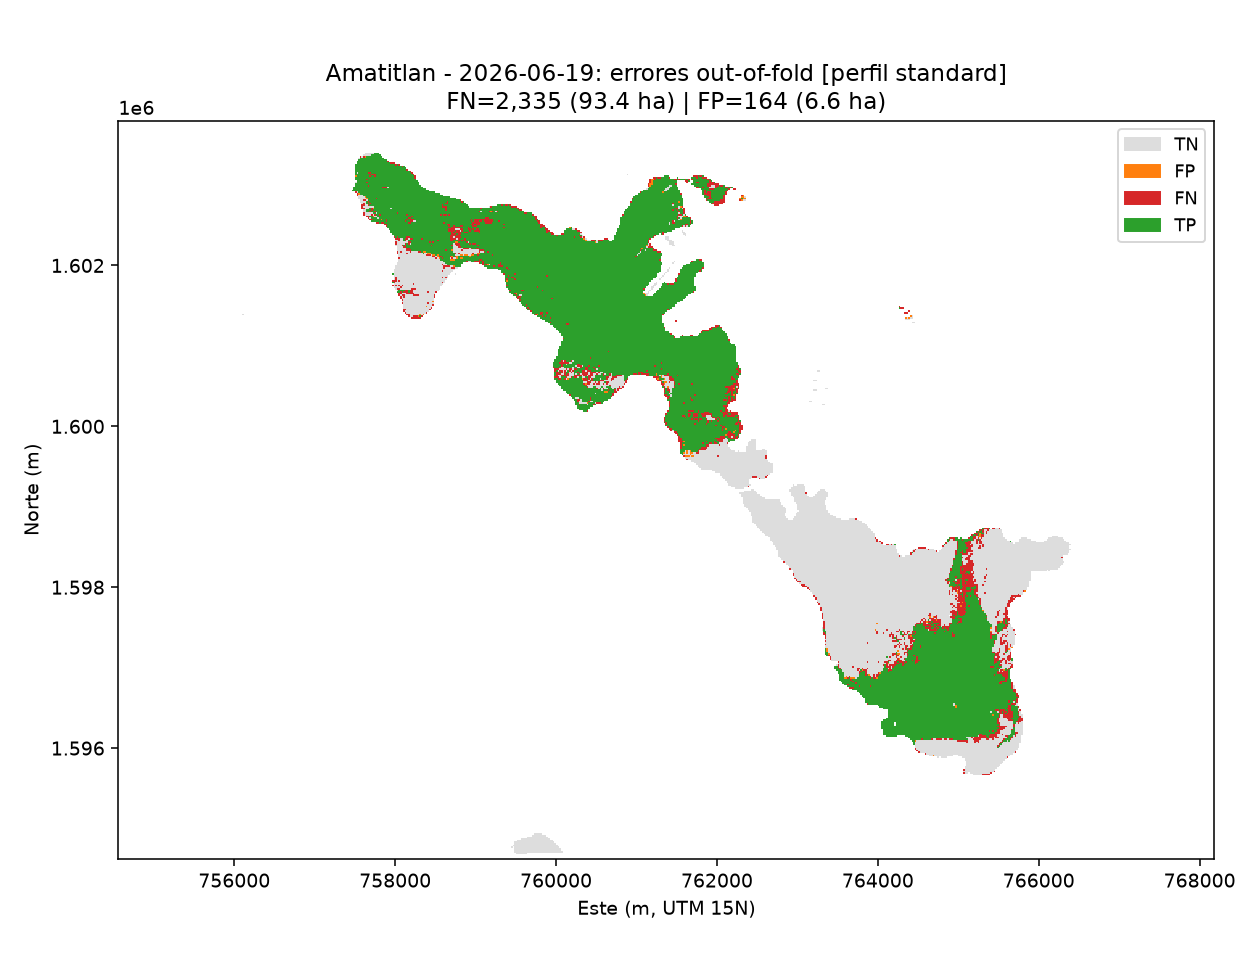

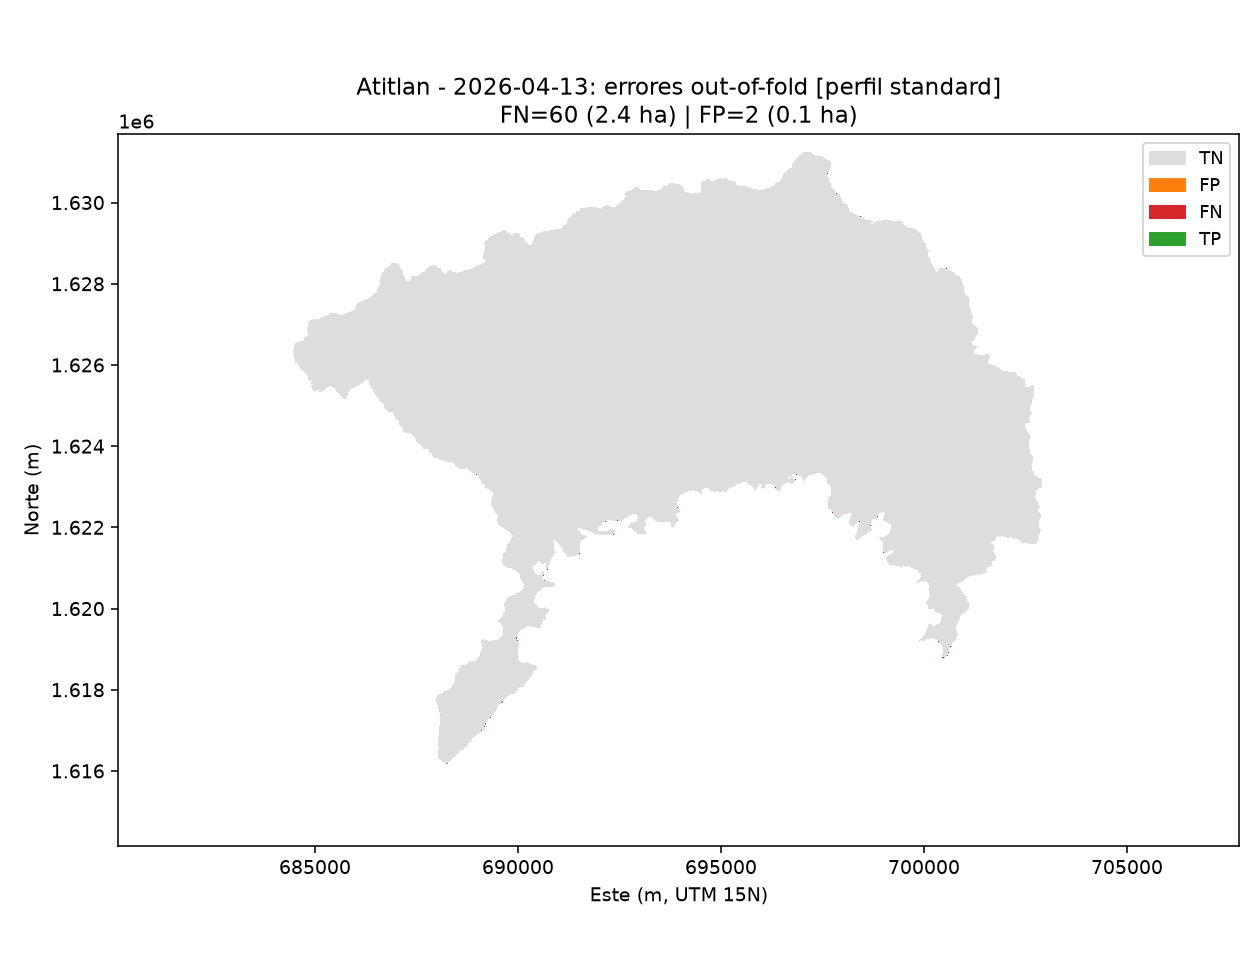

In [37]:
por_lago = pd.read_csv(MAPS / "errors_oof" / "metricas_oof_por_lago_standard.csv")
display(por_lago[["grupo", "n", "pr_auc", "recall", "precision", "TP", "FN", "FP",
                  "area_FN_ha", "area_FP_ha"]].round(4))

display(Image(filename=str(MAPS / "figures" / "errores_oof_Amatitlan_2026-06-19_standard.png")))
display(Image(filename=str(MAPS / "figures" / "errores_oof_Atitlan_2026-04-13_standard.png")))

El **falso negativo es el error ambientalmente más grave**: una zona con floración alta que
no recibe aviso. Por eso la métrica prioritaria es el Recall, complementada con F2.


---

# Ejercicio 10. Conclusiones calculadas


In [38]:
conclusiones = json.loads((CONC / "conclusiones_standard.json").read_text(encoding="utf-8"))

print("=== Comparación de estrategias de validación (PR-AUC) ===")
comp = pd.read_csv(CONC / "comparacion_etapas_standard.csv")
display(comp.round(4))

print("\n=== Generalización entre lagos ===")
display(pd.DataFrame(conclusiones["cross_lake"]))

print(f"\nEmpate práctico espacial: {conclusiones['empate_practico']} "
      f"(diferencia {conclusiones['diferencia_top2_espacial']})")
print(f"Mejor modelo aleatorio: {conclusiones['mejor_aleatorio']}")
print(f"Mejor modelo espacial: {conclusiones['mejor_espacial']}")

=== Comparación de estrategias de validación (PR-AUC) ===


,etapa,modelo,pr_auc,desviacion
0,aleatorio 70/30,random_forest,0.9814,NaN
1,aleatorio 70/30,xgboost,0.9826,NaN
2,aleatorio 70/30,logistic,0.9135,NaN
3,validacion espacial,logistic,0.9026,0.0563
4,validacion espacial,random_forest,0.9758,0.0128
5,validacion espacial,xgboost,0.9757,0.0150
6,validacion temporal,logistic,0.6429,0.2839
7,validacion temporal,random_forest,0.7416,0.2510
8,validacion temporal,xgboost,0.7042,0.2571



=== Generalización entre lagos ===


,experimento,train,test,pr_auc,recall_operacional,TP,FN
0,A,Atitlan,Amatitlan,0.7851,0.0401,2324,55672
1,B,Amatitlan,Atitlan,0.5081,0.1312,282,1868



Empate práctico espacial: True (diferencia 0.0001)
Mejor modelo aleatorio: xgboost
Mejor modelo espacial: random_forest


In [39]:
print("CONCLUSIONES:\n")
for x in conclusiones["conclusiones"]:
    print("-", x)
print("\nLIMITACIONES:\n")
for x in conclusiones["limitaciones"]:
    print("-", x)

CONCLUSIONES:

- El split aleatorio 70/30 es OPTIMISTA: mezcla pixeles vecinos del mismo bloque de 1 km, casi identicos entre si.
- Random Forest y XGBoost estan en EMPATE PRACTICO bajo validacion espacial; la diferencia es menor que la desviacion entre folds.
- Existe INESTABILIDAD TEMPORAL marcada: el desempeno varia fuertemente entre fechas y cae respecto de la validacion espacial.
- La TRANSFERENCIA ENTRE LAGOS NO es satisfactoria: con umbral fijo el recall operacional se desploma en ambas direcciones.
- El modelo sirve como APOYO DE CRIBADO dentro del dominio observado (estos dos lagos, estas fechas, este algoritmo de referencia).
- NO sustituye el monitoreo in situ: no confirma presencia de cianobacterias ni toxicidad.
- NO demuestra transferencia robusta a otros lagos ni a fechas futuras.

LIMITACIONES:

- La respuesta es un PROXY ESPECTRAL de clorofila-a, no una medicion de cianobacterias ni de toxinas.
- No hubo validacion in situ en ninguna fase del laboratorio.
- El algoritm

### Síntesis por estrategia de validación

| Estrategia | Qué mide | Random Forest (PR-AUC) |
|---|---|---|
| Aleatoria 70/30 | Optimista: mezcla vecinos del mismo bloque | 0.9814 |
| **Espacial (bloques 1 km)** | **Predecir en una zona nueva** | **0.9758 ± 0.0128** |
| **Temporal (expansiva)** | **Predecir una fecha futura** | **0.7416 ± 0.2510** |
| Out-of-fold (base de los mapas de error) | Evaluación honesta, sin fuga espacial | 0.9779 |
| Generalización a otro lago | Transferir el modelo a un lago no visto | 0.51–0.79 (PR-AUC) pero Recall 4–13 % |

**Modelo final descriptivo vs. predicciones OOF.** El mapa "descriptivo" del Ejercicio 9 usa un
Random Forest ajustado con todos los datos: es útil para visualizar el despliegue, pero no mide
desempeño porque el modelo ya vio esos píxeles. Los mapas de error OOF, en cambio, usan
predicciones donde cada observación fue evaluada por un modelo que nunca la vio — son la fuente
correcta de cualquier métrica de desempeño espacial.


---

## Estado: Ejercicios 1–10 completados

| Ejercicio | Estado |
|---|---|
| 1–3 Preparación, respuesta, predictores | Completado |
| 4–5 Modelos y evaluación | Completado |
| 6 Validación espacial + temporal | Completado |
| 7 Generalización entre lagos | Completado |
| **8 Interpretabilidad (nativa, permutation, SHAP)** | **Completado** |
| **9 Mapas predictivos y errores OOF** | **Completado** |
| **10 Conclusiones** | **Completado** |

### Documentos de esta entrega

- `INFORME_LAB4_PARTE2.md` — informe académico con cifras reales y figuras incrustadas.
- `ARTICULO_TECNICO_LAB4.md` — artículo técnico pedagógico extendido.
- `outputs/parte2/` — todos los artefactos versionables (CSV, JSON, figuras, reportes).

### Limitaciones finales que deben acompañar cualquier uso del sistema

- Proxy espectral de clorofila-a, sin validación in situ.
- Algoritmo CyanoLakes con MAPE 42.3 % y RMSE relativo 95.8 %.
- Solo 22 escenas; inestabilidad temporal marcada (σ ≈ 0.25).
- Transferencia entre lagos no satisfactoria con umbral fijo.
- Sirve como apoyo de cribado, no como diagnóstico ni sustituto de muestreo físico.
